Module 1: Data Handling

Mount Drive and Verifying Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)

# Dataset path
DATA_PATH = '/content/drive/MyDrive/Corn_Disease_Project/corn-or-maize-leaf-disease-dataset'

print("=" * 60)
print("STEP 1: DATASET VERIFICATION")
print("=" * 60)

if not os.path.exists(DATA_PATH):
    print(" ERROR: Dataset path not found!")
else:
    classes = sorted(os.listdir(DATA_PATH))
    print(f"Found classes: {classes}")
    print()

    total_images = 0
    class_counts = {}

    for cls in classes:
        cls_path = os.path.join(DATA_PATH, cls)
        if os.path.isdir(cls_path):
            # Count all image files recursively
            image_count = 0
            image_files = []
            for root, dirs, files in os.walk(cls_path):
                for file in files:
                    if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp')):
                        image_count += 1
                        image_files.append(os.path.join(root, file))

            class_counts[cls] = image_count
            total_images += image_count
            print(f"  {cls}: {image_count} images")

    print()
    print("-" * 60)
    print(f"EXPECTED: ~{total_images} (auto-detected)")
    print(f"STATUS: COMPLETE")
    print("=" * 60)

STEP 1: DATASET VERIFICATION
Found classes: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy', 'Non_Leaf']

  Blight: 1146 images
  Common_Rust: 1306 images
  Gray_Leaf_Spot: 581 images
  Healthy: 1162 images
  Non_Leaf: 1200 images

------------------------------------------------------------
EXPECTED: ~5395 (auto-detected)
STATUS: COMPLETE


PyTorch Setup & Transforms

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print("\n" + "=" * 60)
print("STEP 2: PYTORCH SETUP & TRANSFORMS  [UPGRADED]")
print("=" * 60)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Image size for EfficientNet-B0
IMG_SIZE = 224

# ── SECTION 1: STRONG AUGMENTATION for real-world robustness ──────────────
# Why each transform:
#   RandomHorizontalFlip  → field photos taken from any angle
#   RandomVerticalFlip    → some phones held inverted
#   RandomRotation(30)    → leaf not always upright in photo
#   RandomAffine          → slight shear/translation mimics handheld shots
#   RandomResizedCrop     → partial leaf, zoomed-in, zoomed-out scenarios
#   ColorJitter (strong)  → different lighting, shadows, golden hour, cloudy
#   RandomGrayscale       → forces model to learn texture not just colour
#   GaussianBlur          → blurred / out-of-focus phone camera shots
#   RandomPerspective     → photo taken at an angle, not perfectly flat
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),      # slightly larger before crop
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=10),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.65, 1.0), ratio=(0.8, 1.25)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.4),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.35, hue=0.07),
    transforms.RandomGrayscale(p=0.08),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=5, sigma=(1.0, 3.0))
    ], p=0.3),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.6, contrast=0.6, saturation=0.5, hue=0.1)
    ], p=0.4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.08)),   # occlusion robustness
])


# Validation / test — only clean preprocessing, NO augmentation
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print(" UPGRADED transforms created")
print("  Training : 11-step strong augmentation pipeline")
print("  Inference: resize + normalize only")



STEP 2: PYTORCH SETUP & TRANSFORMS  [UPGRADED]
Using device: cuda
GPU: Tesla T4
 UPGRADED transforms created
  Training : 11-step strong augmentation pipeline
  Inference: resize + normalize only


Custom Dataset Class

In [4]:
print("\n" + "=" * 60)
print("STEP 3: CUSTOM DATASET CLASS")
print("=" * 60)

class CornLeafDataset(Dataset):
    """
    Custom PyTorch Dataset for Corn Leaf Disease Images
    """
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # Load image
        img_path = self.file_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        return image, label

print(" CornLeafDataset class created")


STEP 3: CUSTOM DATASET CLASS
 CornLeafDataset class created


In [5]:
from PIL import Image, ImageFile
import os

ImageFile.LOAD_TRUNCATED_IMAGES = True

dataset_path = "/content/drive/MyDrive/Corn_Disease_Project/corn-or-maize-leaf-disease-dataset"

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        path = os.path.join(root, file)

        try:
            img = Image.open(path)
            img.verify()

        except:
            print("Removing corrupted:", path)
            os.remove(path)

print("Dataset cleaned successfully!")

Dataset cleaned successfully!


Load All Images

In [6]:
print("\n" + "=" * 60)
print("STEP 4: LOAD ALL IMAGES")
print("=" * 60)

all_image_paths = []
all_labels = []
class_names = sorted(os.listdir(DATA_PATH))
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}

print("Class mapping:")
for cls, idx in class_to_idx.items():
    print(f"  {idx}: {cls}")

for cls in class_names:
    cls_path = os.path.join(DATA_PATH, cls)
    if os.path.isdir(cls_path):
        for root, dirs, files in os.walk(cls_path):
            for file in files:
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    all_image_paths.append(os.path.join(root, file))
                    all_labels.append(class_to_idx[cls])

print(f"\n Loaded {len(all_image_paths)} images")
print(f" Loaded {len(all_labels)} labels")


STEP 4: LOAD ALL IMAGES
Class mapping:
  0: Blight
  1: Common_Rust
  2: Gray_Leaf_Spot
  3: Healthy
  4: Non_Leaf

 Loaded 5395 images
 Loaded 5395 labels


In [7]:
# ── SECTION 5: NON-LEAF CLASS ADDITION ─────────────────────────────────────
import os

DATA_PATH_CHECK = '/content/drive/MyDrive/Corn_Disease_Project/corn-or-maize-leaf-disease-dataset'
nonleaf_path    = os.path.join(DATA_PATH_CHECK, 'Non_Leaf')

if os.path.exists(nonleaf_path):
    count = len([f for f in os.listdir(nonleaf_path)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))])
    print(f" Non_Leaf folder found: {count} images")
    if count < 200:
        print(f" WARNING: Only {count} Non_Leaf images. Recommend 300+.")
    else:
        print(" Non_Leaf class is ready to include in training!")
    print("\nTo activate 5-class mode, the class_names list will be:")
    print("  ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy', 'Non_Leaf']")
    print("And the model classifier output will change to nn.Linear(1280, 5)")
else:
    print(" Non_Leaf folder NOT found.")
    print(f"  Create it at: {nonleaf_path}")
    print("  Place 300–600 non-corn images there, then re-run Module 1.")
    print("\nFor now, confidence thresholding (Section 4) handles unknown images.")
    print("Non_Leaf class adds a second layer of protection when added.")

print("\n── CLASSIFIER UPDATE NEEDED WHEN NON_LEAF IS ADDED ──────────────────")
print("In Module 2 cell 'Load Pretrained EfficientNet-B0', change:")
print("  model.classifier[1] = nn.Linear(num_features, len(class_names))")
print("class_names will auto-expand to 5 classes if Non_Leaf folder exists.")


 Non_Leaf folder found: 1200 images
 Non_Leaf class is ready to include in training!

To activate 5-class mode, the class_names list will be:
  ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy', 'Non_Leaf']
And the model classifier output will change to nn.Linear(1280, 5)

── CLASSIFIER UPDATE NEEDED WHEN NON_LEAF IS ADDED ──────────────────
In Module 2 cell 'Load Pretrained EfficientNet-B0', change:
  model.classifier[1] = nn.Linear(num_features, len(class_names))
class_names will auto-expand to 5 classes if Non_Leaf folder exists.


Train/Test Split (70/30)

In [8]:
print("\n" + "=" * 60)
print("STEP 5: TRAIN / VAL / TEST SPLIT  [UPGRADED — 70/15/15]")
print("=" * 60)

# ── SECTION 2: PROPER STRATIFIED 3-WAY SPLIT ──────────────────────────────
# Why train_test_split instead of random_split:
#   • random_split does NOT guarantee class balance per split
#   • stratify=all_labels ensures each split mirrors overall distribution
#   • random_state=42 gives reproducible identical splits every run
#   → eliminates leakage-like behaviour from unbalanced splits

# Step 1: carve off 30 % as temp (val + test)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths, all_labels,
    test_size=0.30, random_state=42, stratify=all_labels
)

# Step 2: split temp 50/50 → 15 % val, 15 % test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.50, random_state=42, stratify=temp_labels
)

print(f"Training samples : {len(train_paths):,}  ({len(train_paths)/len(all_image_paths)*100:.1f}%)")
print(f"Validation samples: {len(val_paths):,}  ({len(val_paths)/len(all_image_paths)*100:.1f}%)")
print(f"Test samples      : {len(test_paths):,}  ({len(test_paths)/len(all_image_paths)*100:.1f}%)")

print("\nClass distribution in TRAIN:")
for i, cls in enumerate(class_names):
    count = train_labels.count(i)
    print(f"  {cls}: {count} ({count/len(train_labels)*100:.1f}%)")

print("\nClass distribution in VAL:")
for i, cls in enumerate(class_names):
    count = val_labels.count(i)
    print(f"  {cls}: {count} ({count/len(val_labels)*100:.1f}%)")

print("\nClass distribution in TEST:")
for i, cls in enumerate(class_names):
    count = test_labels.count(i)
    print(f"  {cls}: {count} ({count/len(test_labels)*100:.1f}%)")



STEP 5: TRAIN / VAL / TEST SPLIT  [UPGRADED — 70/15/15]
Training samples : 3,776  (70.0%)
Validation samples: 809  (15.0%)
Test samples      : 810  (15.0%)

Class distribution in TRAIN:
  Blight: 802 (21.2%)
  Common_Rust: 914 (24.2%)
  Gray_Leaf_Spot: 407 (10.8%)
  Healthy: 813 (21.5%)
  Non_Leaf: 840 (22.2%)

Class distribution in VAL:
  Blight: 172 (21.3%)
  Common_Rust: 196 (24.2%)
  Gray_Leaf_Spot: 87 (10.8%)
  Healthy: 174 (21.5%)
  Non_Leaf: 180 (22.2%)

Class distribution in TEST:
  Blight: 172 (21.2%)
  Common_Rust: 196 (24.2%)
  Gray_Leaf_Spot: 87 (10.7%)
  Healthy: 175 (21.6%)
  Non_Leaf: 180 (22.2%)


Create DataLoaders


In [9]:
#CHNAGED THIS CELL
print("\n" + "=" * 60)
print("STEP 6: CREATE DATASETS & DATALOADERS")
print("=" * 60)

# Create datasets
train_dataset = CornLeafDataset(train_paths, train_labels, transform=train_transform)
val_dataset   = CornLeafDataset(val_paths,   val_labels,   transform=test_transform)
test_dataset  = CornLeafDataset(test_paths,  test_labels,  transform=test_transform)

# Also define train_dataset_split for Module 5 (Optuna)
# This is 70% of train_dataset used for Optuna trials
from torch.utils.data import random_split
split_train_size = int(0.7 * len(train_dataset))
split_val_size   = len(train_dataset) - split_train_size
train_dataset_split, _ = random_split(
    train_dataset,
    [split_train_size, split_val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f" Train dataset:       {len(train_dataset)} samples")
print(f" Val dataset:         {len(val_dataset)} samples")
print(f" Test dataset:        {len(test_dataset)} samples")
print(f" train_dataset_split: {len(train_dataset_split)} samples (for Module 5)")

# Use pin_memory=False for CPU compatibility
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=False
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=False
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=False
)

print(f" Train loader: {len(train_loader)} batches")
print(f" Val loader:   {len(val_loader)} batches")
print(f" Test loader:  {len(test_loader)} batches")


STEP 6: CREATE DATASETS & DATALOADERS
 Train dataset:       3776 samples
 Val dataset:         809 samples
 Test dataset:        810 samples
 train_dataset_split: 2643 samples (for Module 5)
 Train loader: 118 batches
 Val loader:   26 batches
 Test loader:  26 batches


Class Weights for Imbalance

In [10]:
print("\n" + "=" * 60)
print("STEP 7: CLASS WEIGHTS FOR IMBALANCE")
print("=" * 60)

# Calculate class weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

print("Class weights (to handle imbalance):")
for i, (cls, weight) in enumerate(zip(class_names, class_weights)):
    print(f"  {cls}: {weight:.4f}")

# Convert to tensor for PyTorch
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"\n Class weights tensor created: {class_weights_tensor}")


STEP 7: CLASS WEIGHTS FOR IMBALANCE
Class weights (to handle imbalance):
  Blight: 0.9416
  Common_Rust: 0.8263
  Gray_Leaf_Spot: 1.8555
  Healthy: 0.9289
  Non_Leaf: 0.8990

 Class weights tensor created: tensor([0.9416, 0.8263, 1.8555, 0.9289, 0.8990], device='cuda:0')


 Visualize Samples


STEP 8: VISUALIZE SAMPLE IMAGES
Training samples (with augmentation):


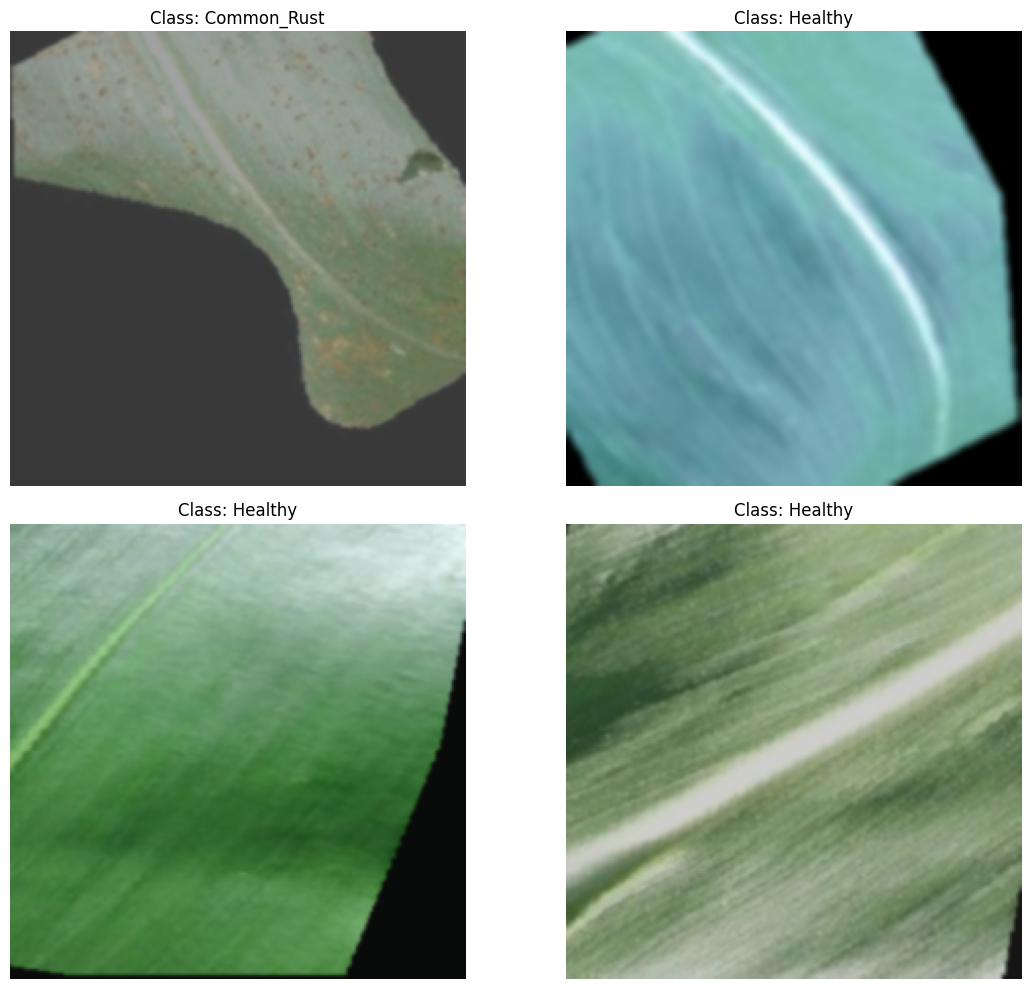

 Sample images saved to Drive

Testing samples (without augmentation):


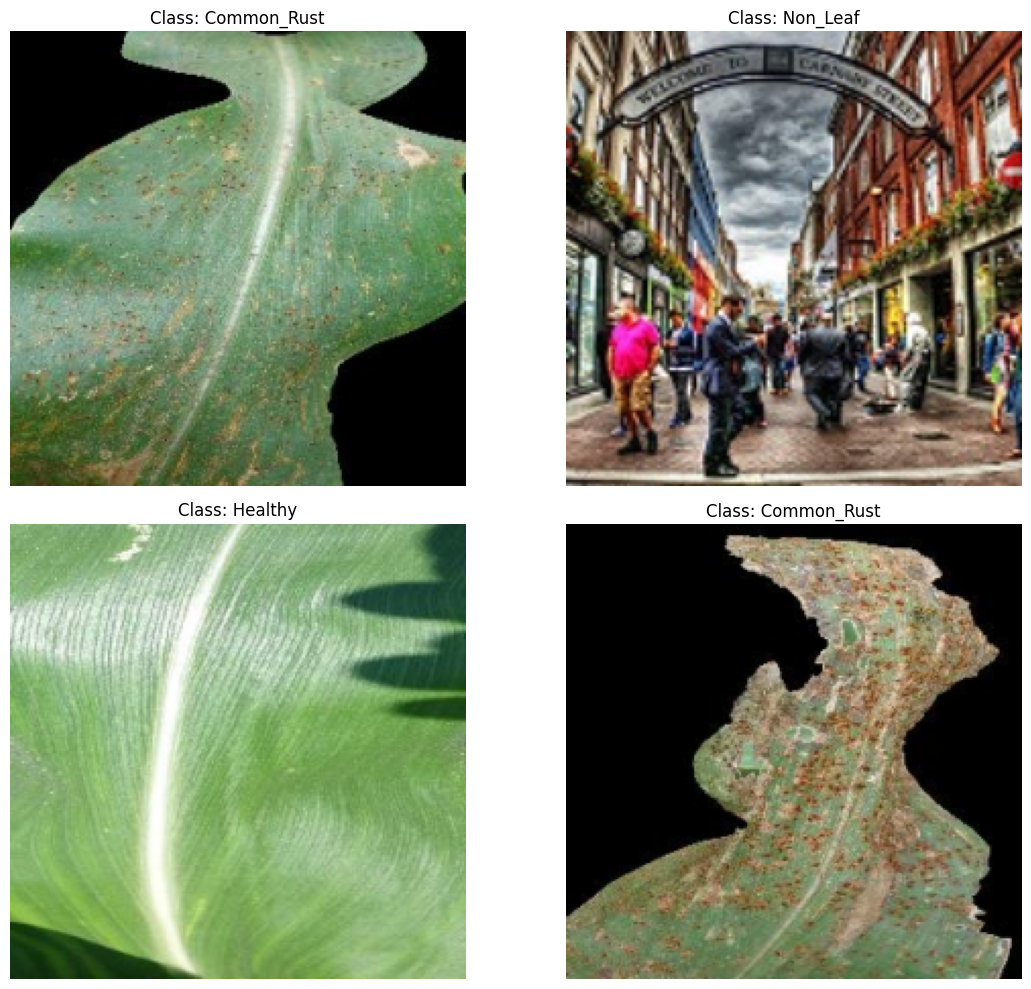

 Sample images saved to Drive


In [11]:
print("\n" + "=" * 60)
print("STEP 8: VISUALIZE SAMPLE IMAGES")
print("=" * 60)

def visualize_samples(dataset, class_names, num_samples=4):
    """Visualize random samples from dataset"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for i in range(num_samples):
        idx = random.randint(0, len(dataset) - 1)
        image, label = dataset[idx]

        # Convert tensor to numpy for display
        image = image.numpy().transpose((1, 2, 0))

        # Denormalize for display
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1)

        axes[i].imshow(image)
        axes[i].set_title(f"Class: {class_names[label]}", fontsize=12)
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/Corn_Disease_Project/sample_images.png', dpi=150)
    plt.show()
    print(" Sample images saved to Drive")

# Visualize training samples
print("Training samples (with augmentation):")
visualize_samples(train_dataset, class_names)

# Visualize test samples
print("\nTesting samples (without augmentation):")
visualize_samples(test_dataset, class_names)

Save Artifacts

In [12]:
#CHANGED THIS CELL
print("\n" + "=" * 60)
print("STEP 9: SAVE ARTIFACTS FOR OTHER MODULES")
print("=" * 60)

import pickle, json

# Save ONLY simple values — no DataLoader or Dataset objects
# This prevents the CUDA/pickle crash in new sessions
clean_artifacts = {
    'class_names':  class_names,
    'class_to_idx': class_to_idx,
    'class_weights': class_weights,           # numpy array, no CUDA issue
    'img_size':     IMG_SIZE,
    'batch_size':   BATCH_SIZE,
    'num_classes':  len(class_names),
    'data_path':    DATA_PATH,
    'train_size':   len(train_dataset),
    'val_size':     len(val_dataset),
    'test_size':    len(test_dataset),
}

artifacts_path = '/content/drive/MyDrive/Corn_Disease_Project/module1_artifacts.pkl'
os.makedirs(os.path.dirname(artifacts_path), exist_ok=True)

with open(artifacts_path, 'wb') as f:
    pickle.dump(clean_artifacts, f)

# Also save as JSON for easy reading
json_path = '/content/drive/MyDrive/Corn_Disease_Project/module1_artifacts.json'
with open(json_path, 'w') as f:
    json.dump({k: (v.tolist() if hasattr(v,'tolist') else v)
               for k, v in clean_artifacts.items()}, f, indent=2)

print(f" Artifacts saved: {artifacts_path}")
print(f" JSON backup:     {json_path}")
print("\nArtifacts saved:")
for k, v in clean_artifacts.items():
    print(f"  - {k}: {v if not hasattr(v,'shape') else v.shape}")

print("\n" + "=" * 60)
print("MODULE 1 COMPLETE! ")
print("=" * 60)
print(f"  • Total images: {len(train_dataset)+len(val_dataset)+len(test_dataset)}")
print(f"  • Training: {len(train_dataset)}")
print(f"  • Validation: {len(val_dataset)}")
print(f"  • Testing: {len(test_dataset)}")
print(f"  • Classes: {class_names}")
print(f"  • Device: {device}")
print("=" * 60)


STEP 9: SAVE ARTIFACTS FOR OTHER MODULES
 Artifacts saved: /content/drive/MyDrive/Corn_Disease_Project/module1_artifacts.pkl
 JSON backup:     /content/drive/MyDrive/Corn_Disease_Project/module1_artifacts.json

Artifacts saved:
  - class_names: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy', 'Non_Leaf']
  - class_to_idx: {'Blight': 0, 'Common_Rust': 1, 'Gray_Leaf_Spot': 2, 'Healthy': 3, 'Non_Leaf': 4}
  - class_weights: (5,)
  - img_size: 224
  - batch_size: 32
  - num_classes: 5
  - data_path: /content/drive/MyDrive/Corn_Disease_Project/corn-or-maize-leaf-disease-dataset
  - train_size: 3776
  - val_size: 809
  - test_size: 810

MODULE 1 COMPLETE! 
  • Total images: 5395
  • Training: 3776
  • Validation: 809
  • Testing: 810
  • Classes: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy', 'Non_Leaf']
  • Device: cuda


Module 2: CV Model Training

Mount Drive and Loading Module 1 Artifacts

In [13]:
#CHANGED THIS CELL
from google.colab import drive
drive.mount('/content/drive')

import pickle, os, torch, torch.nn as nn, numpy as np
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision import transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print("=" * 60)
print("MODULE 2: SETUP")
print("=" * 60)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device: {device}")

# Load the clean artifacts (no pickle CUDA problem)
artifacts_path = '/content/drive/MyDrive/Corn_Disease_Project/module1_artifacts.pkl'
with open(artifacts_path, 'rb') as f:
    arts = pickle.load(f)

class_names  = arts['class_names']
class_to_idx = arts['class_to_idx']
IMG_SIZE     = arts['img_size']
BATCH_SIZE   = arts['batch_size']
DATA_PATH    = arts['data_path']

# Restore class weights tensor on current device
class_weights_np = arts['class_weights']
class_weights    = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

print(f" Loaded: {class_names}")
print(f" Class weights: {class_weights}")

# Redefine dataset class
class CornLeafDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels     = labels
        self.transform  = transform
    def __len__(self):
        return len(self.file_paths)
    def __getitem__(self, idx):
        image = Image.open(self.file_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),      # slightly larger before crop
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=10),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.65, 1.0), ratio=(0.8, 1.25)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.4),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.35, hue=0.07),
    transforms.RandomGrayscale(p=0.08),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=5, sigma=(1.0, 3.0))
    ], p=0.3),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.6, contrast=0.6, saturation=0.5, hue=0.1)
    ], p=0.4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.08)),   # occlusion robustness
])
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Reload image paths and labels
all_image_paths, all_labels = [], []
for cls in class_names:
    cls_path = os.path.join(DATA_PATH, cls)
    if os.path.isdir(cls_path):
        for root, _, files in os.walk(cls_path):
            for file in files:
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    all_image_paths.append(os.path.join(root, file))
                    all_labels.append(class_to_idx[cls])

# Same split as Module 1 (random_state=42 guarantees same split)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths, all_labels, test_size=0.3, random_state=42, stratify=all_labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

# Datasets and loaders
train_dataset = CornLeafDataset(train_paths, train_labels, transform=train_transform)
val_dataset   = CornLeafDataset(val_paths,   val_labels,   transform=test_transform)
test_dataset  = CornLeafDataset(test_paths,  test_labels,  transform=test_transform)

# train_dataset_split needed for Module 5
split_train_size = int(0.7 * len(train_dataset))
split_val_size   = len(train_dataset) - split_train_size
train_dataset_split, _ = random_split(
    train_dataset, [split_train_size, split_val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f" Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print(f" Train loader: {len(train_loader)} batches")
print(" Module 2 setup complete — ready to train")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MODULE 2: SETUP
 Device: cuda
 Loaded: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy', 'Non_Leaf']
 Class weights: tensor([0.9416, 0.8263, 1.8555, 0.9289, 0.8990], device='cuda:0')
 Train: 3776, Val: 809, Test: 810
 Train loader: 118 batches
 Module 2 setup complete — ready to train


Load Pretrained EfficientNet-B0

In [14]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import numpy as np

print("\n" + "=" * 60)
print("STEP 1: LOAD PRETRAINED EFFICIENTNET-B0")
print("=" * 60)

# Load pretrained model
model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

# Modify classifier for 4 classes
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, len(class_names))

print(f" Model loaded: EfficientNet-B0")
print(f" Original classes: 1000 (ImageNet)")
print(f" Modified classes: {len(class_names)} (Corn diseases)")
print(f" Features: {num_features}")


STEP 1: LOAD PRETRAINED EFFICIENTNET-B0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 169MB/s]

 Model loaded: EfficientNet-B0
 Original classes: 1000 (ImageNet)
 Modified classes: 5 (Corn diseases)
 Features: 1280


Transfer Learning — Freeze Early Layers

In [15]:
print("\n" + "=" * 60)
print("STEP 2: TRANSFER LEARNING SETUP  [UPGRADED — PARTIAL UNFREEZE]")
print("=" * 60)

# ── SECTION 3: BETTER FINE-TUNING STRATEGY ────────────────────────────────
# Problem with old approach: ALL features frozen → model only learned
#   a linear mapping on top of ImageNet features, never adapting to
#   corn-specific textures, rust patterns, or lesion shapes.
#
# Fix: freeze early generic layers (edges, colours), unfreeze deep
#   domain-specific layers (blocks 5-8) + classifier.
#   Use a lower LR for backbone to avoid destroying pretrained weights.

# Step 1: freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Step 2: unfreeze the last 3 feature blocks (features[5], [6], [7])
# EfficientNet-B0 features: [0]=stem, [1]-[7]=MBConv blocks, [8]=head conv
for block_idx in [5, 6, 7, 8]:
    for param in model.features[block_idx].parameters():
        param.requires_grad = True

# Step 3: always unfreeze classifier
for param in model.classifier.parameters():
    param.requires_grad = True

# Diagnostics
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}  ({trainable_params/total_params*100:.1f}%)")
print(f"Frozen parameters    : {frozen_params:,}  ({frozen_params/total_params*100:.1f}%)")
print(" Deep blocks [5,6,7,8] + classifier are now trainable")
print(" Early blocks [0-4] remain frozen (generic edge/colour features)")

# Move model to device
model = model.to(device)
print(f" Model moved to {device}")



STEP 2: TRANSFER LEARNING SETUP  [UPGRADED — PARTIAL UNFREEZE]
Total parameters     : 4,013,953
Trainable parameters : 3,705,293  (92.3%)
Frozen parameters    : 308,660  (7.7%)
 Deep blocks [5,6,7,8] + classifier are now trainable
 Early blocks [0-4] remain frozen (generic edge/colour features)
 Model moved to cuda


Loss, Optimizer, Scheduler

In [16]:
print("\n" + "=" * 60)
print("STEP 3: LOSS, OPTIMIZER, SCHEDULER  [UPGRADED]")
print("=" * 60)

# ── SECTION 3 + 10: DIFFERENTIAL LR + AdamW + COSINE SCHEDULE ─────────────
# Why AdamW over Adam?  Weight decay in AdamW is correct (decoupled),
#   preventing the classifier from over-fitting small training sets.
# Why differential LRs?  Backbone features need gentle nudging;
#   the new classifier head needs faster learning.
# Why CosineAnnealingLR?  Smooth LR decay avoids sharp jumps that
#   destabilise the partially-frozen backbone.

# Loss with class-weights (handles Gray_Leaf_Spot underrepresentation)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print(" Loss: CrossEntropyLoss with class weights")

# Differential learning rates
backbone_params    = [p for n, p in model.named_parameters()
                      if 'classifier' not in n and p.requires_grad]
classifier_params  = list(model.classifier.parameters())

optimizer = torch.optim.AdamW([
    {'params': backbone_params,   'lr': 3e-5, 'weight_decay': 1e-4},
    {'params': classifier_params, 'lr': 3e-4, 'weight_decay': 1e-4},
])
print(" Optimizer: AdamW")
print("   backbone  (blocks 5-8) lr=3e-5, wd=1e-4")
print("   classifier              lr=3e-4, wd=1e-4")

# Cosine annealing over 25 epochs
T_MAX = 25
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_MAX, eta_min=1e-7)
print(f" Scheduler: CosineAnnealingLR (T_max={T_MAX}, eta_min=1e-7)")



STEP 3: LOSS, OPTIMIZER, SCHEDULER  [UPGRADED]
 Loss: CrossEntropyLoss with class weights
 Optimizer: AdamW
   backbone  (blocks 5-8) lr=3e-5, wd=1e-4
   classifier              lr=3e-4, wd=1e-4
 Scheduler: CosineAnnealingLR (T_max=25, eta_min=1e-7)


Training & Evaluation Functions

In [17]:
print("\n" + "=" * 60)
print("STEP 4: TRAINING & EVALUATION FUNCTIONS")
print("=" * 60)

def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Statistics
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Print progress every 20 batches
        if (batch_idx + 1) % 20 == 0:
            print(f"  Batch [{batch_idx+1}/{len(loader)}] Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

def evaluate(model, loader, criterion, device):
    """Evaluate on test set"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total

    return avg_loss, accuracy, all_preds, all_labels

print(" Training and evaluation functions defined")


STEP 4: TRAINING & EVALUATION FUNCTIONS
 Training and evaluation functions defined


In [18]:
import os

checkpoint_path = '/content/drive/MyDrive/Corn_Disease_Project/models/latest_checkpoint.pth'

if os.path.exists(checkpoint_path):
    os.remove(checkpoint_path)
    print("Old 4-class checkpoint deleted — will start fresh training with 5 classes")
else:
    print("No checkpoint found — already clean")

No checkpoint found — already clean


In [19]:
import os

for old_file in ['latest_checkpoint.pth', 'best_corn_model.pth']:
    path = f'/content/drive/MyDrive/Corn_Disease_Project/models/{old_file}'
    if os.path.exists(path):
        os.remove(path)
        print(f"Deleted: {old_file}")

In [20]:
print("\n" + "=" * 60)
print("STEP 5: TRAINING LOOP  [UPGRADED — 25 EPOCHS + LABEL SMOOTHING]")
print("=" * 60)

EPOCHS       = 25
LABEL_SMOOTH = 0.10
PATIENCE     = 6

criterion_smooth = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTH)
print(f" Label smoothing = {LABEL_SMOOTH}  →  reduces overconfidence")

best_accuracy = 0
best_epoch    = 0
start_epoch   = 0
no_improve    = 0

train_losses, train_accs = [], []
val_losses,   val_accs   = [], []

save_dir = '/content/drive/MyDrive/Corn_Disease_Project/models'
os.makedirs(save_dir, exist_ok=True)

checkpoint_path = f'{save_dir}/latest_checkpoint.pth'

if os.path.exists(checkpoint_path):
    print("Found checkpoint — resuming...")
    ckpt = torch.load(checkpoint_path, map_location=device)

    # ── Always restore model weights ──────────────────────────────────────
    model.load_state_dict(ckpt['model_state_dict'])

    # ── Restore optimizer ONLY if parameter group count matches ───────────
    # Mismatch happens when you switch from old Adam (1 group: classifier only)
    # to new AdamW (2 groups: backbone + classifier). Safe to skip in that case
    # because the model weights are already restored — only LR schedule is lost.
    saved_groups   = ckpt['optimizer_state_dict']['param_groups']
    current_groups = optimizer.param_groups
    if len(saved_groups) == len(current_groups):
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        print(" Optimizer state restored")
    else:
        print(f" Optimizer groups mismatch: checkpoint has {len(saved_groups)}, "
              f"current has {len(current_groups)}.")
        print(" Skipping optimizer state — using fresh AdamW (model weights kept).")
        print(" This is normal when switching from old Adam to new AdamW.")

    # ── Restore scheduler if state was saved ──────────────────────────────
    if 'scheduler_state' in ckpt:
        try:
            scheduler.load_state_dict(ckpt['scheduler_state'])
            print(" Scheduler state restored")
        except Exception as e:
            print(f" Scheduler state skipped ({e}) — starting fresh schedule")

    start_epoch   = ckpt['epoch'] + 1
    best_accuracy = ckpt.get('best_accuracy', 0)
    best_epoch    = ckpt.get('best_epoch', 0)
    train_losses  = ckpt.get('train_losses', [])
    train_accs    = ckpt.get('train_accs', [])
    val_losses    = ckpt.get('val_losses', [])
    val_accs      = ckpt.get('val_accs', [])

    print(f" Resuming from epoch {start_epoch + 1}, best so far = {best_accuracy:.2f}%")
else:
    print("No checkpoint found — starting fresh training...")

print(f" Training for {EPOCHS} epochs on {device}")

# ── Training loop ──────────────────────────────────────────────────────────
for epoch in range(start_epoch, EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print("-" * 40)

    train_loss, train_acc = train_epoch(model, train_loader, criterion_smooth, optimizer, device)
    val_loss, val_acc, preds, labs = evaluate(model, val_loader, criterion_smooth, device)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    train_losses.append(train_loss); train_accs.append(train_acc)
    val_losses.append(val_loss);     val_accs.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")
    print(f"LR: {current_lr:.2e}")

    if val_acc > best_accuracy:
        best_accuracy = val_acc
        best_epoch    = epoch + 1
        no_improve    = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'accuracy': val_acc,
            'class_names': class_names,
            'class_to_idx': class_to_idx,
        }, f'{save_dir}/best_corn_model.pth')
        print(f" Best model saved! Acc={val_acc:.2f}%")
    else:
        no_improve += 1
        print(f" No improvement ({no_improve}/{PATIENCE})")

    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_accuracy': best_accuracy, 'best_epoch': best_epoch,
        'train_losses': train_losses, 'train_accs': train_accs,
        'val_losses': val_losses,     'val_accs': val_accs,
        'scheduler_state': scheduler.state_dict(),
        'class_names': class_names,
        'class_to_idx': class_to_idx,
    }, checkpoint_path)
    print(f" Checkpoint saved (Epoch {epoch+1})")

    torch.save(model.state_dict(), f'{save_dir}/epoch_{epoch+1}.pth')

    if no_improve >= PATIENCE:
        print(f"\n Early stopping triggered after {PATIENCE} epochs without improvement.")
        break

print("\n" + "=" * 60)
print("TRAINING COMPLETE!")
print("=" * 60)
print(f"Best Val Accuracy : {best_accuracy:.2f}%  (Epoch {best_epoch})")
print(f"Model saved       : {save_dir}/best_corn_model.pth")


STEP 5: TRAINING LOOP  [UPGRADED — 25 EPOCHS + LABEL SMOOTHING]
 Label smoothing = 0.1  →  reduces overconfidence
No checkpoint found — starting fresh training...
 Training for 25 epochs on cuda

Epoch [1/25]
----------------------------------------
  Batch [20/118] Loss: 1.3737
  Batch [40/118] Loss: 1.1682
  Batch [60/118] Loss: 1.0194
  Batch [80/118] Loss: 0.7670
  Batch [100/118] Loss: 0.8033
Train Loss: 1.0861 | Train Acc: 73.31%
Val   Loss: 0.7848 | Val   Acc: 84.05%
LR: 2.99e-05
 Best model saved! Acc=84.05%
 Checkpoint saved (Epoch 1)

Epoch [2/25]
----------------------------------------
  Batch [20/118] Loss: 0.8469
  Batch [40/118] Loss: 0.6342
  Batch [60/118] Loss: 0.7124
  Batch [80/118] Loss: 0.6566
  Batch [100/118] Loss: 0.8251
Train Loss: 0.7319 | Train Acc: 87.10%
Val   Loss: 0.6546 | Val   Acc: 90.23%
LR: 2.95e-05
 Best model saved! Acc=90.23%
 Checkpoint saved (Epoch 2)

Epoch [3/25]
----------------------------------------
  Batch [20/118] Loss: 0.6264
  Batch [

Training Loop (Main Training)

In [21]:
import os

save_dir = '/content/drive/MyDrive/Corn_Disease_Project/models'

# Check karo ke epoch 20 complete hua ya nahi
files = os.listdir(save_dir) if os.path.exists(save_dir) else []
epoch_files = [f for f in files if f.startswith('epoch_')]

print("Saved epoch files:")
for f in sorted(epoch_files):
    print(f"   {f}")

if 'epoch_20.pth' in files:
    print("\n TRAINING COMPLETE! Epoch 20 done!")
elif 'epoch_16.pth' in files:
    print("\n Training stopped at epoch 16 — need to resume!")
else:
    print("\n No epoch files found")

Saved epoch files:
   epoch_1.pth
   epoch_10.pth
   epoch_11.pth
   epoch_12.pth
   epoch_13.pth
   epoch_14.pth
   epoch_15.pth
   epoch_16.pth
   epoch_17.pth
   epoch_18.pth
   epoch_19.pth
   epoch_2.pth
   epoch_3.pth
   epoch_4.pth
   epoch_5.pth
   epoch_6.pth
   epoch_7.pth
   epoch_8.pth
   epoch_9.pth

 Training stopped at epoch 16 — need to resume!


Plot Training Curves


STEP 6: PLOT TRAINING CURVES
 Loaded history: 19 epochs
 Best accuracy: 94.07% at epoch 13


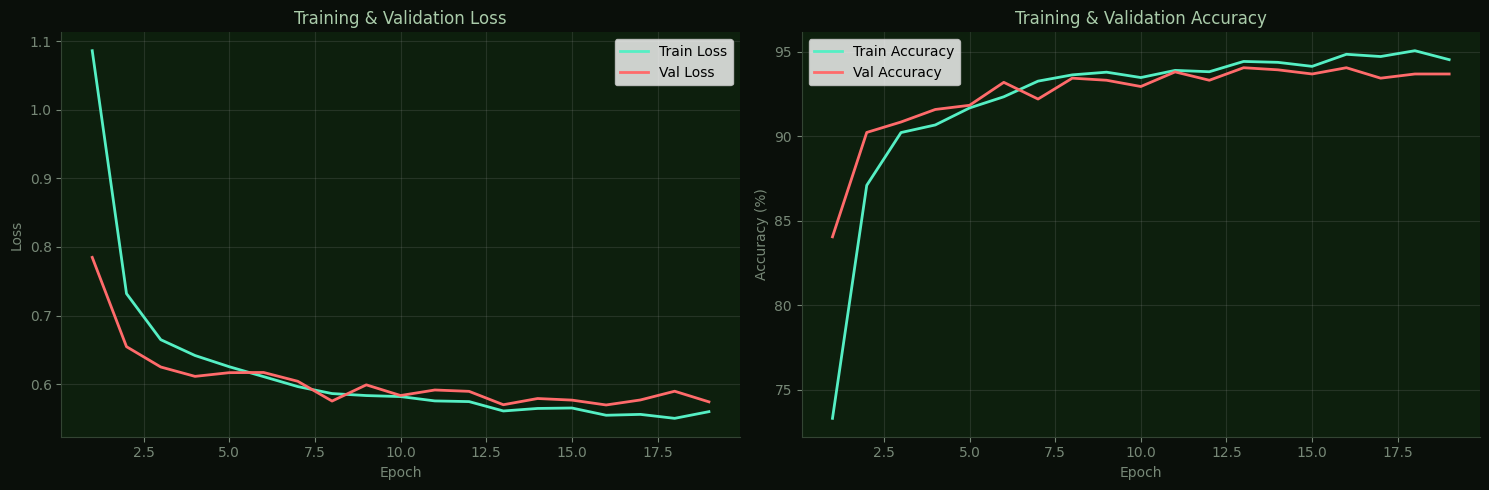

 Training curves saved


In [22]:
#CHANGED THIS CELL
import matplotlib.pyplot as plt

print("\n" + "=" * 60)
print("STEP 6: PLOT TRAINING CURVES")
print("=" * 60)

# Load history from checkpoint (works even after session restart)
save_dir = '/content/drive/MyDrive/Corn_Disease_Project/models'
ckpt_path = f'{save_dir}/latest_checkpoint.pth'

ckpt = torch.load(ckpt_path, map_location='cpu')
train_losses = ckpt['train_losses']
train_accs   = ckpt['train_accs']
val_losses   = ckpt['val_losses']
val_accs     = ckpt['val_accs']
EPOCHS       = len(train_losses)

print(f" Loaded history: {EPOCHS} epochs")
print(f" Best accuracy: {ckpt['best_accuracy']:.2f}% at epoch {ckpt['best_epoch']}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#0A0F0A')

for ax in [ax1, ax2]:
    ax.set_facecolor('#0D1F0D')
    ax.spines['bottom'].set_color('#334433')
    ax.spines['left'].set_color('#334433')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(colors='#778877')
    ax.yaxis.label.set_color('#778877')
    ax.xaxis.label.set_color('#778877')
    ax.title.set_color('#AACCAA')

epochs_range = range(1, EPOCHS + 1)
ax1.plot(epochs_range, train_losses, color='#55EFC4', linewidth=2, label='Train Loss')
ax1.plot(epochs_range, val_losses,   color='#FF6B6B', linewidth=2, label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss'); ax1.legend(); ax1.grid(alpha=0.15)

ax2.plot(epochs_range, train_accs, color='#55EFC4', linewidth=2, label='Train Accuracy')
ax2.plot(epochs_range, val_accs,   color='#FF6B6B', linewidth=2, label='Val Accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training & Validation Accuracy'); ax2.legend(); ax2.grid(alpha=0.15)

plt.tight_layout()
plt.savefig(f'{save_dir}/training_curves.png', dpi=150, facecolor='#0A0F0A')
plt.show()
print(" Training curves saved")

Detailed Evaluation Metrics


STEP 7: DETAILED EVALUATION  [UPGRADED]
 Best model loaded: 94.07% val accuracy

Classification Report:
                precision    recall  f1-score   support

        Blight     0.8889    0.9302    0.9091       172
   Common_Rust     0.9890    0.9184    0.9524       196
Gray_Leaf_Spot     0.8202    0.8391    0.8295        87
       Healthy     0.9831    0.9943    0.9886       175
      Non_Leaf     0.9890    1.0000    0.9945       180

      accuracy                         0.9469       810
     macro avg     0.9340    0.9364    0.9348       810
  weighted avg     0.9483    0.9469    0.9472       810

Per-class breakdown:
Class                 Precision     Recall         F1    Support
------------------------------------------------------------
Blight                   0.8889     0.9302     0.9091        172
Common_Rust              0.9890     0.9184     0.9524        196
Gray_Leaf_Spot           0.8202     0.8391     0.8295         87
Healthy                  0.9831     0.9943    

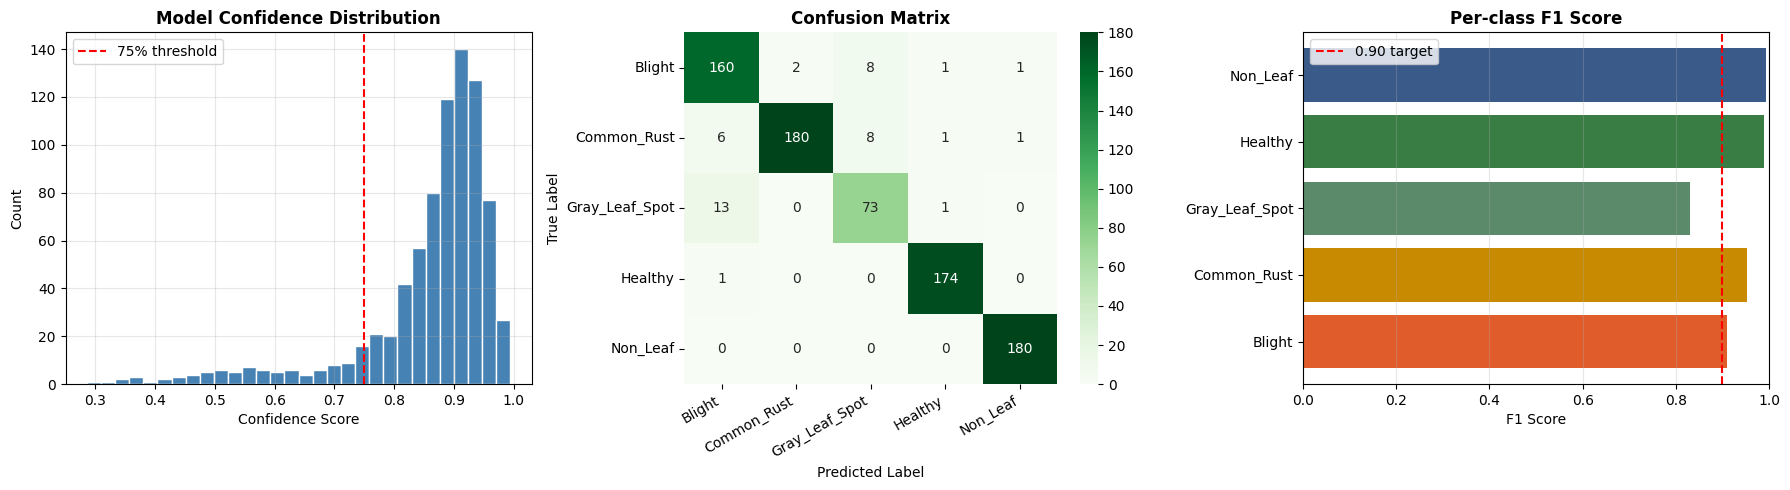


── HOW TO INTERPRET ──────────────────────────────────────────
Precision : of all 'X' predictions, how many were truly 'X'?
Recall    : of all true 'X' images, how many did we catch?
F1        : harmonic mean of precision and recall (balance)
Low recall on a disease class  → model is MISSING real disease cases
Low precision on a class       → model is FALSE-ALARMING on that class
Class imbalance signal         → support column very unequal?
                                 → check class_weights were applied
Overconfidence signal          → confidence histogram piled near 1.0?
                                 → label smoothing + threshold help
Confusion hotspots             → off-diagonal cells in confusion matrix
                                 → those two classes need more examples
Confidence mean: 85.8%
Predictions below 75% threshold: 95/810 (11.7%)
  These would be flagged as 'Unknown / Invalid Leaf Image' in production


In [25]:
#CHANGED THIS CELL — SECTION 11: FULL EVALUATION METRICS
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_recall_fscore_support)
import seaborn as sns
import matplotlib.pyplot as plt

print("\n" + "=" * 60)
print("STEP 7: DETAILED EVALUATION  [UPGRADED]")
print("=" * 60)

# ── SECTION 11: CONFUSION MATRIX + PER-CLASS METRICS ─────────────────────
save_dir = '/content/drive/MyDrive/Corn_Disease_Project/models'
best_ckpt = torch.load(f'{save_dir}/best_corn_model.pth', map_location=device)

model_eval = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
num_features = model_eval.classifier[1].in_features
model_eval.classifier[1] = nn.Linear(num_features, len(class_names))
model_eval.load_state_dict(best_ckpt['model_state_dict'])
model_eval = model_eval.to(device)
model_eval.eval()
print(f" Best model loaded: {best_ckpt['accuracy']:.2f}% val accuracy")

# Collect predictions + confidences
all_preds, all_labels_eval, all_confs = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_eval(images)
        probs   = torch.softmax(outputs, dim=1)
        conf, predicted = probs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels_eval.extend(labels.cpu().numpy())
        all_confs.extend(conf.cpu().numpy())

# ── 1. Classification report ──
print("\nClassification Report:")
print(classification_report(all_labels_eval, all_preds, target_names=class_names, digits=4))

# ── 2. Per-class precision / recall / F1 ──
prec, rec, f1, sup = precision_recall_fscore_support(
    all_labels_eval, all_preds, average=None, labels=list(range(len(class_names)))
)
print("Per-class breakdown:")
print(f"{'Class':<20} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
print("-" * 60)
for i, cls in enumerate(class_names):
    print(f"{cls:<20} {prec[i]:>10.4f} {rec[i]:>10.4f} {f1[i]:>10.4f} {sup[i]:>10}")

# ── 3. Confidence histogram ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(all_confs, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Model Confidence Distribution', fontweight='bold')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Count')
axes[0].axvline(0.75, color='red', linestyle='--', label='75% threshold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── 4. Confusion matrix ──
cm = confusion_matrix(all_labels_eval, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix', fontweight='bold')
axes[1].set_ylabel('True Label')

axes[1].set_xlabel('Predicted Label')

torch.save(
    model_eval.state_dict(),
    '/content/drive/MyDrive/Corn_Disease_Project/best_corn_model_optimized.pth'
)


plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

# ── 5. Per-class F1 bar ──
axes[2].barh(class_names, f1, color=['#e05c2a','#c88a00','#5a8a6a','#3a7d44','#3a5a8a'])
axes[2].set_xlim(0, 1)
axes[2].set_title('Per-class F1 Score', fontweight='bold')
axes[2].set_xlabel('F1 Score')
axes[2].axvline(0.9, color='red', linestyle='--', label='0.90 target')
axes[2].legend()
axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{save_dir}/evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 6. Interpretation guide ──
print("\n── HOW TO INTERPRET ──────────────────────────────────────────")
print("Precision : of all 'X' predictions, how many were truly 'X'?")
print("Recall    : of all true 'X' images, how many did we catch?")
print("F1        : harmonic mean of precision and recall (balance)")
print("Low recall on a disease class  → model is MISSING real disease cases")
print("Low precision on a class       → model is FALSE-ALARMING on that class")
print("Class imbalance signal         → support column very unequal?")
print("                                 → check class_weights were applied")
print("Overconfidence signal          → confidence histogram piled near 1.0?")
print("                                 → label smoothing + threshold help")
print("Confusion hotspots             → off-diagonal cells in confusion matrix")
print("                                 → those two classes need more examples")
print("Confidence mean:", f"{sum(all_confs)/len(all_confs)*100:.1f}%")
low_conf = sum(1 for c in all_confs if c < 0.75)
print(f"Predictions below 75% threshold: {low_conf}/{len(all_confs)} "
      f"({low_conf/len(all_confs)*100:.1f}%)")
print("  These would be flagged as 'Unknown / Invalid Leaf Image' in production")


Save Module 2 Artifacts

In [26]:
print("\n" + "=" * 60)
print("STEP 8: SAVE MODULE 2 ARTIFACTS")
print("=" * 60)

# Save model architecture info
model_info = {
    'model': model,
    'class_names': class_names,
    'class_to_idx': class_to_idx,
    'num_classes': len(class_names),
    'img_size': IMG_SIZE,
    'best_accuracy': best_accuracy,
    'best_epoch': best_epoch,
    'device': device
}

# Save for Module 4 (XAI) and Frontend
torch.save(model.state_dict(), f'{save_dir}/model_state_dict.pth')

# Save complete info
module2_path = '/content/drive/MyDrive/Corn_Disease_Project/module2_model.pkl'
with open(module2_path, 'wb') as f:
    pickle.dump(model_info, f)

print(f" Model state dict: {save_dir}/model_state_dict.pth")
print(f" Model info: {module2_path}")
print(f" Best checkpoint: {save_dir}/best_corn_model.pth")

print("\n" + "=" * 60)
print("MODULE 2 COMPLETE! ")
print("=" * 60)
print("\nSummary:")
print(f"  • Model: EfficientNet-B0 (transfer learning)")
print(f"  • Best Accuracy: {best_accuracy:.2f}%")
print(f"  • Best Epoch: {best_epoch}/{EPOCHS}")
print(f"  • Total Parameters: {total_params:,}")
print(f"  • Trainable Parameters: {trainable_params:,}")
print(f"  • Model saved to Drive")
print("\nNext: Module 4 (XAI Grad-CAM) can now load this model")
print("=" * 60)


STEP 8: SAVE MODULE 2 ARTIFACTS
 Model state dict: /content/drive/MyDrive/Corn_Disease_Project/models/model_state_dict.pth
 Model info: /content/drive/MyDrive/Corn_Disease_Project/module2_model.pkl
 Best checkpoint: /content/drive/MyDrive/Corn_Disease_Project/models/best_corn_model.pth

MODULE 2 COMPLETE! 

Summary:
  • Model: EfficientNet-B0 (transfer learning)
  • Best Accuracy: 94.07%
  • Best Epoch: 13/19
  • Total Parameters: 4,013,953
  • Trainable Parameters: 3,705,293
  • Model saved to Drive

Next: Module 4 (XAI Grad-CAM) can now load this model


Module 3:  (NLP Report Gen)

Cell 1: Load Everything from Module 1 & 2

In [27]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision import transforms
from PIL import Image
import pickle
import os
import io
import cv2
import numpy as np

print("=" * 60)
print("MODULE 3: NLP REPORT GENERATION")
print("=" * 60)

# Force device to CPU
device = torch.device('cpu')
print(f" Using device: {device}")

# Redefine CornLeafDataset
class CornLeafDataset(torch.utils.data.Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.file_paths)
    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

print(" CornLeafDataset redefined")

# ===== FIX: Custom unpickler that forces CPU loading =====
class CPU_Unpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch._utils' and name == '_rebuild_tensor_v2':
            # Override tensor rebuilding to use CPU
            return lambda storage, storage_offset, size, stride, requires_grad, backward_hooks: \
                torch.tensor(storage[storage_offset:storage_offset + torch.prod(torch.tensor(size))],
                           dtype=storage.dtype, device='cpu').reshape(size)
        return super().find_class(module, name)

# Alternative simpler approach - just catch and use torch.load with CPU
print("Loading Module 1 artifacts...")

# Method: Load pickle but handle CUDA tensors
try:
    # First try: normal load (might fail if CUDA not available)
    with open('/content/drive/MyDrive/Corn_Disease_Project/module1_artifacts.pkl', 'rb') as f:
        m1 = pickle.load(f)
except RuntimeError:
    # Second try: Load with CPU override
    print(" Normal load failed, using CPU override...")

    # Read the pickle file raw bytes
    with open('/content/drive/MyDrive/Corn_Disease_Project/module1_artifacts.pkl', 'rb') as f:
        raw_data = f.read()

    # Replace CUDA device references with CPU in the raw bytes
    # This is a hack but works for simple cases
    raw_data = raw_data.replace(b'cuda:0', b'cpu')
    raw_data = raw_data.replace(b'cuda', b'cpu')

    m1 = pickle.loads(raw_data)

class_names = m1['class_names']
class_to_idx = m1['class_to_idx']
IMG_SIZE = m1['img_size']

print(f" Module 1 loaded: {class_names}")

# Load Module 2 Model - FORCE CPU
model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, len(class_names))

checkpoint = torch.load(
    '/content/drive/MyDrive/Corn_Disease_Project/models/best_corn_model.pth',
    map_location='cpu'
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f" Model loaded: Best accuracy {checkpoint['accuracy']:.2f}%")

# Image transform
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print(" All artifacts loaded successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MODULE 3: NLP REPORT GENERATION
 Using device: cpu
 CornLeafDataset redefined
Loading Module 1 artifacts...
 Module 1 loaded: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy', 'Non_Leaf']
 Model loaded: Best accuracy 94.07%
 All artifacts loaded successfully!


Cell 2: Advisory Templates + Prediction Function

In [28]:
# ===== ADVISORY TEMPLATES =====
temperature = 1.5
ADVISORY_TEMPLATES = {
    "Blight": {
        "description": "Blight is a fungal disease caused by Exserohilum turcicum that causes elongated brown spots on corn leaves.",
        "symptoms": [
            "Brown/necrotic spots on leaves",
            "Spots may have yellow halos",
            "Leaves may dry and die prematurely"
        ],
        "treatment": [
            "Apply fungicide containing mancozeb or chlorothalonil",
            "Remove and destroy infected plant debris",
            "Ensure proper spacing for air circulation"
        ],
        "prevention": [
            "Use resistant corn varieties (e.g., H99, H95)",
            "Rotate crops (do not plant corn in same field for 2 years)",
            "Avoid overhead irrigation"
        ]
    },
    "Common_Rust": {
        "description": "Common Rust is caused by Puccinia sorghi fungus, producing distinctive rust-colored pustules.",
        "symptoms": [
            "Brown/rust-colored pustules on leaves",
            "Pustules on both upper and lower leaf surfaces",
            "Yellowing of surrounding tissue"
        ],
        "treatment": [
            "Apply fungicide with azoxystrobin or propiconazole",
            "Treat within 48 hours of detection",
            "Repeat application after 7-10 days if needed"
        ],
        "prevention": [
            "Plant resistant hybrids (e.g., Pioneer 33M54)",
            "Monitor fields during humid weather (>70% humidity)",
            "Maintain field hygiene"
        ]
    },
    "Gray_Leaf_Spot": {
        "description": "Gray Leaf Spot is caused by Cercospora zeae-maydis, producing rectangular gray lesions.",
        "symptoms": [
            "Gray to tan rectangular lesions on leaves",
            "Lesions run parallel to leaf veins",
            "Severe infection causes leaf blighting"
        ],
        "treatment": [
            "Apply strobilurin or triazole fungicides",
            "Begin treatment at first sign of disease",
            "Consider fungicide rotation to prevent resistance"
        ],
        "prevention": [
            "Rotate with non-host crops (soybean, wheat)",
            "Till crop residue to reduce overwintering",
            "Use resistant varieties"
        ]
    },
    "Healthy": {
        "description": "Your corn plant appears healthy with no visible disease symptoms.",
        "symptoms": ["No disease symptoms detected"],
        "treatment": ["No treatment needed"],
        "prevention": [
            "Continue regular monitoring",
            "Maintain good agricultural practices",
            "Ensure proper nutrition and irrigation"
        ]
    },
    "Non_Leaf": {
        "description": "The uploaded image does not appear to be a corn or maize leaf.",
        "symptoms": ["No corn leaf detected in the image"],
        "treatment": ["No treatment required"],
        "prevention": ["Please upload a clear, well-lit photo of a corn leaf"]
    },
}

# ──────────────────────────────────────────────────────────────────────────
# SECTION 6: IMAGE VALIDATION
# Validates image before inference — blocks corrupt/tiny/non-image files
# ──────────────────────────────────────────────────────────────────────────
def validate_image(image_path):
    """
    Check image health before inference.
    Returns (ok: bool, reason: str)
    """
    if not os.path.exists(image_path):
        return False, "File does not exist"
    if os.path.getsize(image_path) < 2048:          # less than 2 KB
        return False, "File too small — likely corrupted or empty"
    try:
        img = Image.open(image_path)
        img.verify()                                 # checks for corruption
        img = Image.open(image_path).convert('RGB') # reopen after verify
    except Exception as e:
        return False, f"Cannot open image: {e}"

    w, h = img.size
    if w < 50 or h < 50:
        return False, f"Image too small ({w}x{h}px) — minimum 50x50"
    if w > 8000 or h > 8000:
        return False, f"Image unusually large ({w}x{h}px) — check file"
    # Check if image is not all-black / all-white (blank)
    import numpy as np
    arr = np.array(img.resize((64, 64)))
    if arr.std() < 5.0:
        return False, "Image appears blank or nearly uniform — unusable"
    return True, "OK"


# ──────────────────────────────────────────────────────────────────────────
# SECTION 4 + 9: ROBUST PREDICTION WITH CONFIDENCE THRESHOLD + TOP-K
# ──────────────────────────────────────────────────────────────────────────
CONFIDENCE_THRESHOLD = 0.75   # below this → reject as unknown/invalid

def predict_disease(image_path, model=None, device=None, threshold=CONFIDENCE_THRESHOLD):
    """
    Predict corn leaf disease with:
      • Image validation (Section 6)
      • Confidence threshold rejection (Section 4)
      • Top-2 predictions (Section 9)
      • Structured return dict

    Returns dict with keys:
      status          : 'ok' | 'rejected' | 'error'
      predicted_class : class name or 'Unknown / Invalid Leaf Image'
      confidence      : float 0-100
      top2            : [(class, confidence), (class, confidence)]
      all_probs       : dict {class: prob}
      reason          : human-readable string
    """
    if model is None or device is None:
        return {'status': 'error', 'reason': 'Model or device not provided'}

    # Step 1: Validate image
    valid, reason = validate_image(image_path)
    if not valid:
        return {
            'status'          : 'error',
            'predicted_class' : 'Unknown / Invalid Leaf Image',
            'confidence'      : 0.0,
            'top2'            : [],
            'all_probs'       : {},
            'reason'          : f'Image validation failed: {reason}',
        }

    # Step 2: Preprocess
    try:
        img = Image.open(image_path).convert('RGB')
        transform_infer = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        img_tensor = transform_infer(img).unsqueeze(0).to(device)
    except Exception as e:
        return {
            'status'          : 'error',
            'predicted_class' : 'Unknown / Invalid Leaf Image',
            'confidence'      : 0.0,
            'top2'            : [],
            'all_probs'       : {},
            'reason'          : f'Preprocessing failed: {e}',
        }

    # Step 3: Inference
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        outputs = outputs / temperature
        probs   = torch.softmax(outputs, dim=1)[0]   # shape: [num_classes]

    prob_list   = probs.cpu().tolist()
    all_probs   = {cn: round(p * 100, 2) for cn, p in zip(class_names, prob_list)}

    # Top-2 (Section 9)
    top2_idx    = probs.topk(2).indices.cpu().tolist()
    top2        = [(class_names[i], round(prob_list[i] * 100, 2)) for i in top2_idx]

    top_conf    = prob_list[top2_idx[0]]
    top_class   = class_names[top2_idx[0]]

    # Step 4: Confidence threshold rejection (Section 4)
    if top_conf < threshold:
        return {
            'status'          : 'rejected',
            'predicted_class' : 'Unknown / Invalid Leaf Image',
            'confidence'      : round(top_conf * 100, 2),
            'top2'            : top2,
            'all_probs'       : all_probs,
            'reason'          : (
                f'Confidence {top_conf*100:.1f}% is below threshold '
                f'{threshold*100:.0f}%. Image may not be a corn leaf, '
                f'or may be too blurry / partial.'
            ),
        }

    # Step 5: Accepted prediction
    return {
        'status'          : 'ok',
        'predicted_class' : top_class,
        'confidence'      : round(top_conf * 100, 2),
        'top2'            : top2,
        'all_probs'       : all_probs,
        'reason'          : 'Prediction accepted',
    }


def generate_advisory(disease_name, confidence_score):
    """Generate structured advisory report from template"""
    if disease_name not in ADVISORY_TEMPLATES:
        disease_name = 'Unknown / Invalid Leaf Image'
    if disease_name == 'Unknown / Invalid Leaf Image':
        return (
            "=" * 60 + "\n"
            "CORN LEAF DISEASE DIAGNOSIS REPORT\n" +
            "=" * 60 + "\n\n"
            "Result: UNKNOWN / INVALID LEAF IMAGE\n"
            f"Confidence: {confidence_score:.1f}%\n\n"
            "The model could not confidently identify this image as a\n"
            "corn leaf.  Possible reasons:\n"
            "  • Image is not a corn / maize leaf\n"
            "  • Image is blurry, dark, or heavily occluded\n"
            "  • Leaf is only partially visible\n"
            "  • Unusual lighting (very bright / very dark)\n\n"
            "RECOMMENDATION:\n"
            "  Retake photo in natural daylight, leaf filling ≥60% of frame.\n" +
            "=" * 60
        )

    template = ADVISORY_TEMPLATES[disease_name]

    if confidence_score >= 90:
        severity = "HIGH CONFIDENCE"
    elif confidence_score >= 75:
        severity = "MODERATE CONFIDENCE"
    else:
        severity = "LOW CONFIDENCE - Please consult expert"

    report  = "=" * 60 + "\n"
    report += "CORN LEAF DISEASE DIAGNOSIS REPORT\n"
    report += "=" * 60 + "\n\n"
    report += f"Detected Disease: {disease_name.replace('_', ' ')}\n"
    report += f"Confidence Score: {confidence_score:.2f}%\n"
    report += f"Severity Level:   {severity}\n\n"
    report += f"DISEASE DESCRIPTION:\n{template['description']}\n\n"
    report += "OBSERVED SYMPTOMS:\n"
    for s in template['symptoms']:
        report += f"  • {s}\n"
    report += "\nRECOMMENDED TREATMENT:\n"
    for t in template['treatment']:
        report += f"  • {t}\n"
    report += "\nPREVENTION TIPS:\n"
    for p in template['prevention']:
        report += f"  • {p}\n"
    report += (
        "\n" + "=" * 60 + "\n"
        "NOTE: This is an AI-generated advisory.\n"
        "For severe infections, consult an agronomist.\n" +
        "=" * 60
    )
    return report

print(" Advisory templates and robust predict_disease() ready!")
print(f" Confidence threshold: {CONFIDENCE_THRESHOLD*100:.0f}%")
print(" predict_disease() now returns: status, predicted_class, confidence, top2, all_probs, reason")


 Advisory templates and robust predict_disease() ready!
 Confidence threshold: 75%
 predict_disease() now returns: status, predicted_class, confidence, top2, all_probs, reason


Cell 3: BERT Summarization Setup


In [29]:
from transformers import BartTokenizer, BartForConditionalGeneration
import torch

print("\n" + "=" * 60)
print("BERT SUMMARIZATION SETUP")
print("=" * 60)

# Load BART model and tokenizer directly (no pipeline)
try:
    print("Loading BART model...")
    tokenizer = BartTokenizer.from_pretrained("facebook/bart-large-cnn")
    bart_model = BartForConditionalGeneration.from_pretrained("facebook/bart-large-cnn")

    # Move to device if GPU available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    bart_model = bart_model.to(device)
    bart_model.eval()

    print(" BART model loaded successfully")

except Exception as e:
    print(f" BART failed: {e}")
    print("Loading lighter DistilBART model...")

    tokenizer = BartTokenizer.from_pretrained("sshleifer/distilbart-cnn-12-6")
    bart_model = BartForConditionalGeneration.from_pretrained("sshleifer/distilbart-cnn-12-6")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    bart_model = bart_model.to(device)
    bart_model.eval()

    print(" DistilBART loaded")

def generate_bert_summary(report_text, max_length=60, min_length=15):
    """Generate concise BERT-based summary"""
    try:
        # Clean text
        clean_text = report_text.replace('=', '').replace('•', '').replace('\n', ' ')
        clean_text = ' '.join(clean_text.split())

        # Truncate if too long
        if len(clean_text) > 1024:
            clean_text = clean_text[:1024]

        # Tokenize
        inputs = tokenizer([clean_text], max_length=1024, return_tensors='pt', truncation=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # Generate summary
        summary_ids = bart_model.generate(
            inputs['input_ids'],
            num_beams=4,
            max_length=max_length,
            min_length=min_length,
            early_stopping=True
        )

        # Decode
        summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
        return summary

    except Exception as e:
        print(f"Summary error: {e}")
        # Fallback
        lines = [l for l in report_text.split('\n') if l.strip() and not l.startswith('=') and not l.startswith('NOTE')]
        return ' '.join(lines[:2]) if lines else "Summary not available."

print(" BERT summary function ready!")


BERT SUMMARIZATION SETUP
Loading BART model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

 BART model loaded successfully
 BERT summary function ready!


Cell 4: Combined Report + Test


In [30]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Move the main model to device
model = model.to(device)

# Move tokenizer and BART model to device
if 'tokenizer' in dir():
    bart_model = bart_model.to(device)
    print(f"✓ BART model moved to {device}")

def generate_bert_summary(report_text, model=None, tokenizer=None, device=device):
    """
    Generate BERT summary with proper device handling
    """
    if model is None or tokenizer is None:
        print(" BART model not available, returning text summary...")
        # Return first 200 characters as fallback
        return report_text[:200] + "..."

    try:
        # Ensure model is on correct device
        model = model.to(device)

        # Tokenize input
        inputs = tokenizer.encode(report_text, return_tensors='pt', max_length=1024, truncation=True)

        # IMPORTANT: Move input tensors to device
        inputs = inputs.to(device)

        # Generate summary
        summary_ids = model.generate(inputs, max_length=100, min_length=30, do_sample=False)

        # Decode summary
        summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

        return summary

    except Exception as e:
        print(f"⚠️ Error generating BERT summary: {str(e)}")
        return report_text[:200] + "..."


def generate_complete_report(image_path, use_bert=True, model=model, device=device):
    """
    FULL PIPELINE: Image → Prediction → Report → BERT Summary
    """
    # Step 1: Predict disease from image
    result = predict_disease(image_path, model=model, device=device)
    predicted_class = result['predicted_class']
    confidence = result['confidence']

    # Step 2: Generate full advisory report
    full_report = generate_advisory(predicted_class, confidence)

    # Step 3: Generate BERT summary
    bert_summary = None
    if use_bert:
        print("Generating BERT summary...")
        bert_summary = generate_bert_summary(full_report, model=bart_model, tokenizer=tokenizer, device=device)
        print("✓ BERT summary generated")

    return {
        'predicted_disease': predicted_class,
        'confidence': confidence,
        'full_report': full_report,
        'bert_summary': bert_summary
    }


# ===== TEST WITH A SAMPLE IMAGE =====
print("\n" + "=" * 60)
print("TESTING COMPLETE NLP MODULE")
print("=" * 60)

# Find a test image
test_class = "Common_Rust"
test_path = f'/content/drive/MyDrive/Corn_Disease_Project/corn-or-maize-leaf-disease-dataset/{test_class}'
test_images = [f for f in os.listdir(test_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

if test_images:
    sample_image = os.path.join(test_path, test_images[0])
    print(f"\nTesting with: {sample_image}")

    result = generate_complete_report(sample_image, use_bert=True)

    print(f"\n{'='*60}")
    print(f"PREDICTED: {result['predicted_disease']} ({result['confidence']:.2f}%)")
    print(f"{'='*60}")

    print(f"\n BERT QUICK SUMMARY:")
    print(result['bert_summary'])

    print(f"\n FULL REPORT:")
    print(result['full_report'][:500] + "...")
else:
    print(" No test images found!")

Using device: cuda
✓ BART model moved to cuda

TESTING COMPLETE NLP MODULE

Testing with: /content/drive/MyDrive/Corn_Disease_Project/corn-or-maize-leaf-disease-dataset/Common_Rust/Corn_Common_Rust (1274).jpg
Generating BERT summary...
✓ BERT summary generated

PREDICTED: Unknown / Invalid Leaf Image (49.68%)

 BERT QUICK SUMMARY:
The model could not confidently identify this image as a corn leaf. Possible reasons: blurry, dark, or heavily occluded. Retake photo in natural daylight, leaf filling ≥60% of frame.

 FULL REPORT:
CORN LEAF DISEASE DIAGNOSIS REPORT

Result: UNKNOWN / INVALID LEAF IMAGE
Confidence: 49.7%

The model could not confidently identify this image as a
corn leaf.  Possible reasons:
  • Image is not a corn / maize leaf
  • Image is blurry, dark, or heavily occluded
  • Leaf is only partially visible
  • Unusual lighting (very bright / very dark)

RECOMMENDATION:
  Retake photo i...


Cell 5: Save NLP Artifacts


In [31]:
print("\n" + "=" * 60)
print("STEP 5: SAVE NLP ARTIFACTS")
print("=" * 60)

# Save all NLP functions and templates
nlp_artifacts = {
    'ADVISORY_TEMPLATES': ADVISORY_TEMPLATES,
    'class_names': class_names,
    'class_to_idx': class_to_idx,
    'generate_advisory': generate_advisory,
    'generate_bert_summary': generate_bert_summary,
    'generate_complete_report': generate_complete_report,
    'predict_disease': predict_disease
}

nlp_path = '/content/drive/MyDrive/Corn_Disease_Project/module3_nlp_artifacts.pkl'
with open(nlp_path, 'wb') as f:
    pickle.dump(nlp_artifacts, f)

print(f" NLP artifacts saved to: {nlp_path}")
print("\n" + "=" * 60)
print("MODULE 3 COMPLETE! ")
print("=" * 60)
print("\nSummary:")
print("  • Disease prediction from image")
print("  • Template-based advisory report")
print("  • BERT summarization")
print("  • All artifacts saved to Drive")
print("\nNext: Module 4 (XAI Grad-CAM)")
print("=" * 60)


STEP 5: SAVE NLP ARTIFACTS
 NLP artifacts saved to: /content/drive/MyDrive/Corn_Disease_Project/module3_nlp_artifacts.pkl

MODULE 3 COMPLETE! 

Summary:
  • Disease prediction from image
  • Template-based advisory report
  • BERT summarization
  • All artifacts saved to Drive

Next: Module 4 (XAI Grad-CAM)


Module 4


MODULE 4: GRAD-CAM EXPLAINABLE AI
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 102.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✓ Libraries installed and imported
✓ Model ready on cuda
✓ Grad-CAM initialized

GENERATING GRAD-CAM VISUALIZATIONS

🔍 Processing Blight...
✓ Saved: /content/drive/MyDrive/Corn_Disease_Project/gradcam_Blight.png


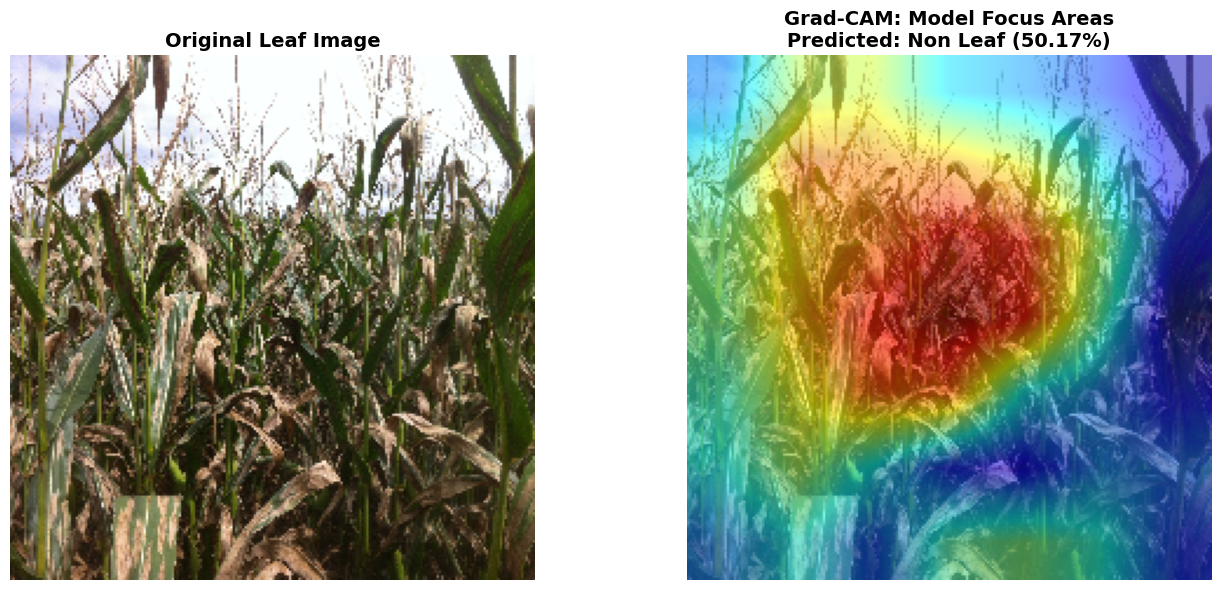

   ✓ Blight: Predicted as Non_Leaf (50.17%)

🔍 Processing Common_Rust...
✓ Saved: /content/drive/MyDrive/Corn_Disease_Project/gradcam_Common_Rust.png


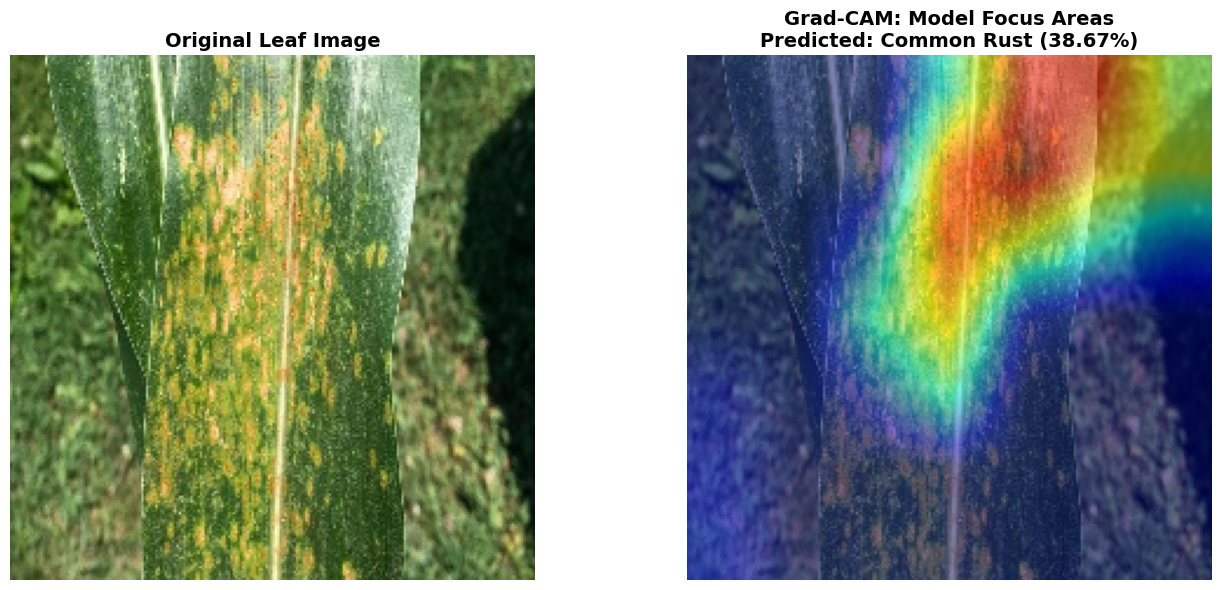

   ✓ Common_Rust: Predicted as Common_Rust (38.67%)

🔍 Processing Gray_Leaf_Spot...
✓ Saved: /content/drive/MyDrive/Corn_Disease_Project/gradcam_Gray_Leaf_Spot.png


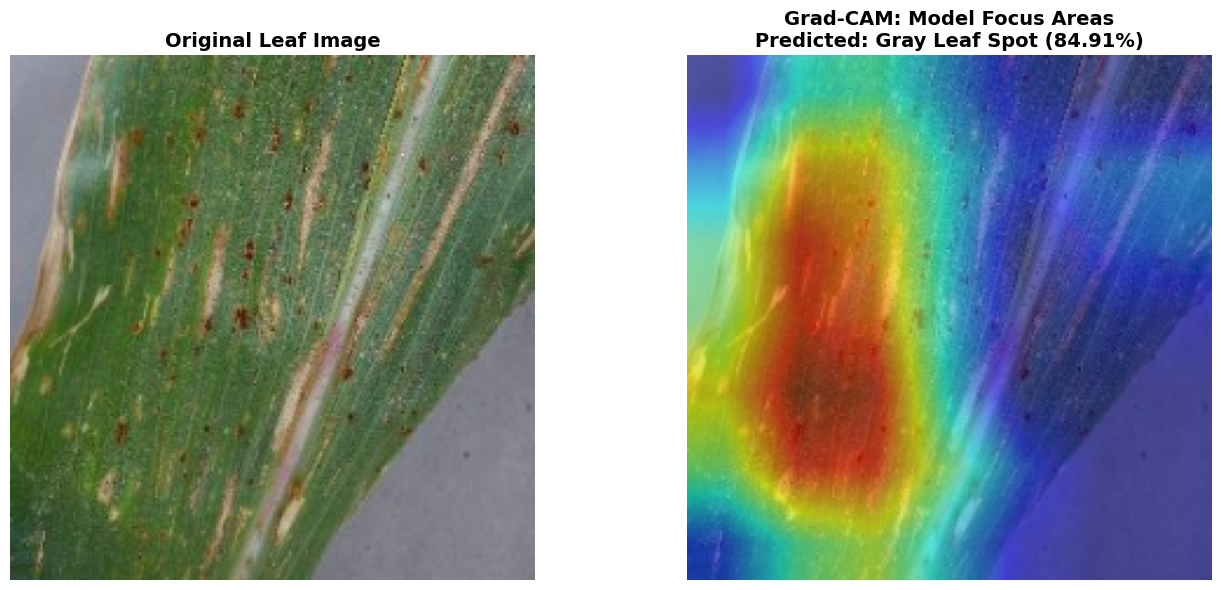

   ✓ Gray_Leaf_Spot: Predicted as Gray_Leaf_Spot (84.91%)

🔍 Processing Healthy...
✓ Saved: /content/drive/MyDrive/Corn_Disease_Project/gradcam_Healthy.png


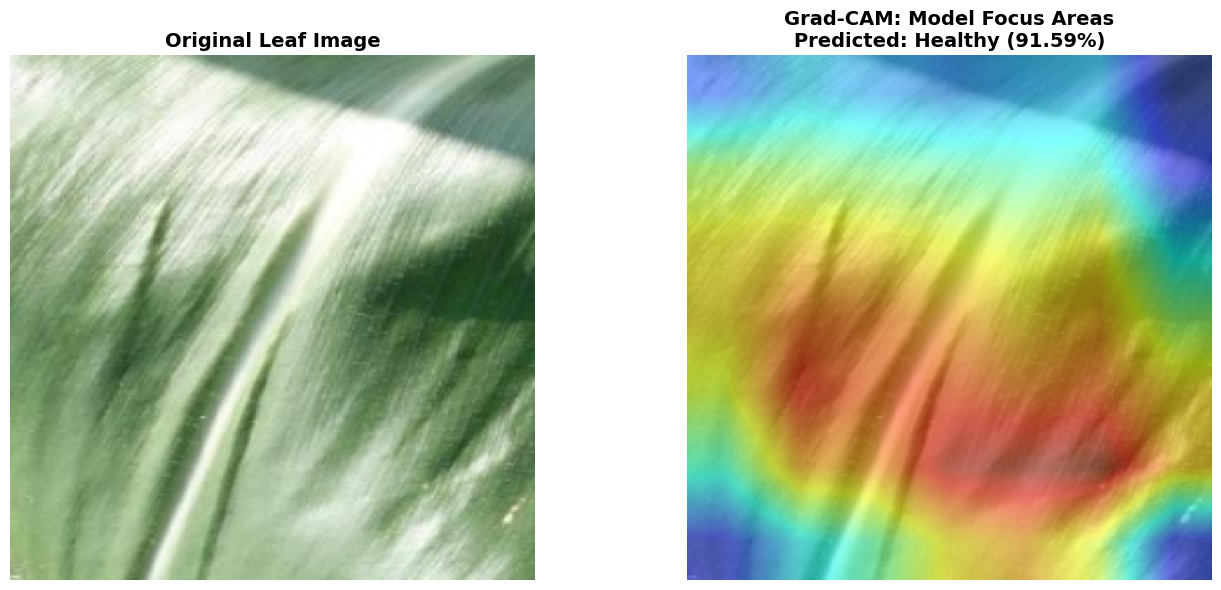

   ✓ Healthy: Predicted as Healthy (91.59%)

🔍 Processing Non_Leaf...
✓ Saved: /content/drive/MyDrive/Corn_Disease_Project/gradcam_Non_Leaf.png


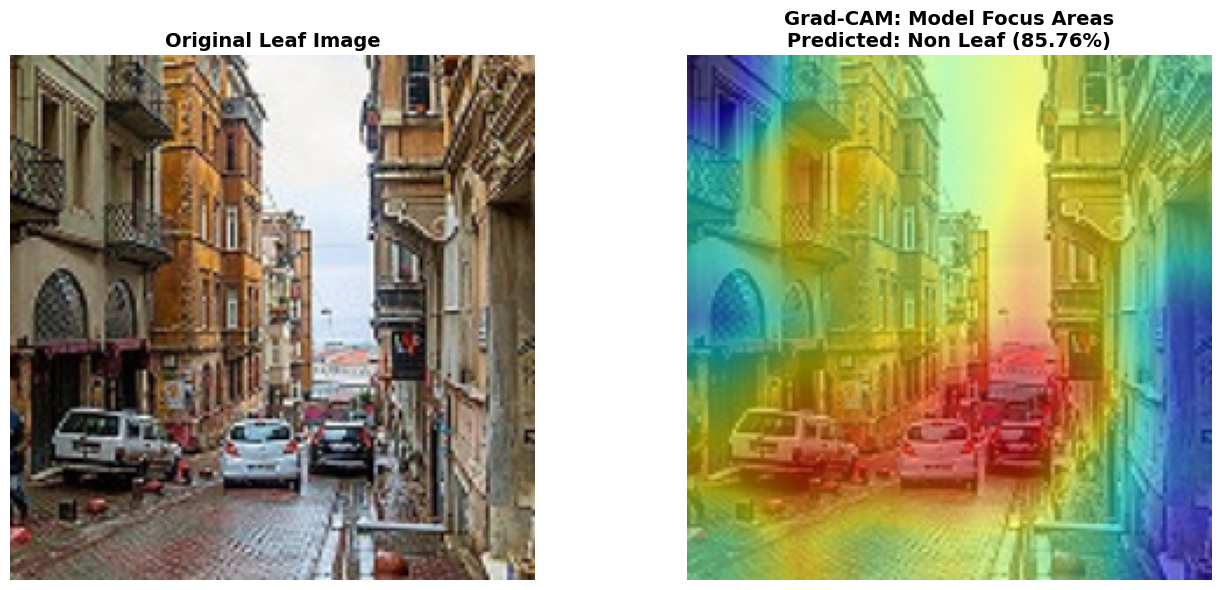

   ✓ Non_Leaf: Predicted as Non_Leaf (85.76%)

GRAD-CAM ANALYSIS COMPLETE

✓ Generated 5 visualizations
✓ Each visualization shows:
   • Left: Original leaf image
   • Right: Grad-CAM heatmap (red = high influence, blue = low influence)

✓ Visualizations saved to Google Drive:
   • gradcam_Blight.png
   • gradcam_Common_Rust.png
   • gradcam_Gray_Leaf_Spot.png
   • gradcam_Healthy.png
   • gradcam_Non_Leaf.png

✓ Grad-CAM artifacts saved to: module4_gradcam_artifacts.pkl

MODULE 4 COMPLETE!

What you've learned:
  • Grad-CAM shows which image regions influence predictions
  • Red/warm colors = high influence on the prediction
  • Blue/cool colors = low influence on the prediction
  • This makes the model's decision EXPLAINABLE


In [32]:
# =========================================
# MODULE 4: EXPLAINABLE AI (Grad-CAM)
# =========================================

print("\n" + "="*60)
print("MODULE 4: GRAD-CAM EXPLAINABLE AI")
print("="*60)

# Step 1: Install and import required libraries
!pip install grad-cam -q

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import matplotlib.pyplot as plt
import cv2

print("✓ Libraries installed and imported")

# Step 2: Ensure model is in eval mode and on correct device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()
print(f"✓ Model ready on {device}")

# Step 3: Create Grad-CAM visualizer
target_layers = [model.features[-1][0]]
cam = GradCAM(model=model, target_layers=target_layers)

print("✓ Grad-CAM initialized")

# Step 4: Function to generate Grad-CAM visualization
def generate_gradcam_visualization(image_path, model, cam, device, class_names, save_path=None):
    """
    Generate Grad-CAM heatmap for a single image
    Shows which regions the model focused on
    """

    # Load image
    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ Could not load image: {image_path}")
        return None

    # Preprocess
    img = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_normalized = img_rgb.astype(np.float32) / 255.0

    # Convert to tensor
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    img_tensor = transform(Image.fromarray(img_rgb)).unsqueeze(0).to(device)

    # Get prediction
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    predicted_class_idx = predicted.item()
    predicted_class = class_names[predicted_class_idx]
    confidence_score = confidence.item() * 100

    # Generate Grad-CAM heatmap
    targets = [ClassifierOutputTarget(predicted_class_idx)]
    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]

    # Create visualization (overlay heatmap on original image)
    visualization = show_cam_on_image(img_normalized, grayscale_cam, use_rgb=True)

    # Create figure with side-by-side comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Original image
    axes[0].imshow(img_rgb)
    axes[0].set_title('Original Leaf Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # Grad-CAM heatmap
    axes[1].imshow(visualization)
    axes[1].set_title(
        f'Grad-CAM: Model Focus Areas\nPredicted: {predicted_class.replace("_", " ")} ({confidence_score:.2f}%)',
        fontsize=14, fontweight='bold'
    )
    axes[1].axis('off')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")

    plt.show()

    return {
        'predicted_class': predicted_class,
        'confidence': confidence_score,
        'heatmap': grayscale_cam,
        'visualization': visualization
    }

# Step 5: Test with sample images from each disease class
print("\n" + "="*60)
print("GENERATING GRAD-CAM VISUALIZATIONS")
print("="*60)

save_dir = '/content/drive/MyDrive/Corn_Disease_Project/models'
best_ckpt = torch.load(f'{save_dir}/best_corn_model.pth', map_location=device)
class_names = best_ckpt['class_names']
dataset_path = '/content/drive/MyDrive/Corn_Disease_Project/corn-or-maize-leaf-disease-dataset'

# Get one sample image from each class
test_images = {}
for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)
    if os.path.exists(class_path):
        images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
        if images:
            test_images[class_name] = os.path.join(class_path, images[0])

# Generate visualizations
gradcam_results = {}
for class_name, image_path in test_images.items():
    print(f"\n🔍 Processing {class_name}...")

    result = generate_gradcam_visualization(
        image_path,
        model,
        cam,
        device,
        class_names,
        save_path=f'/content/drive/MyDrive/Corn_Disease_Project/gradcam_{class_name}.png'
    )

    if result:
        gradcam_results[class_name] = result
        print(f"   ✓ {class_name}: Predicted as {result['predicted_class']} ({result['confidence']:.2f}%)")

# Step 6: Summary
print("\n" + "="*60)
print("GRAD-CAM ANALYSIS COMPLETE")
print("="*60)

print(f"\n✓ Generated {len(gradcam_results)} visualizations")
print("✓ Each visualization shows:")
print("   • Left: Original leaf image")
print("   • Right: Grad-CAM heatmap (red = high influence, blue = low influence)")
print("\n✓ Visualizations saved to Google Drive:")
for class_name in gradcam_results.keys():
    print(f"   • gradcam_{class_name}.png")

# Step 7: Save Grad-CAM results
import pickle

gradcam_artifacts = {
    'results': gradcam_results,
    'class_names': class_names,
    'model_device': str(device)
}

with open('/content/drive/MyDrive/Corn_Disease_Project/module4_gradcam_artifacts.pkl', 'wb') as f:
    pickle.dump(gradcam_artifacts, f)

print("\n✓ Grad-CAM artifacts saved to: module4_gradcam_artifacts.pkl")

print("\n" + "="*60)
print("MODULE 4 COMPLETE!")
print("="*60)
print("\nWhat you've learned:")
print("  • Grad-CAM shows which image regions influence predictions")
print("  • Red/warm colors = high influence on the prediction")
print("  • Blue/cool colors = low influence on the prediction")
print("  • This makes the model's decision EXPLAINABLE")


## Section 8 — Grad-CAM Debugging & Shortcut Detection

SECTION 8: GRAD-CAM DEBUGGING & SHORTCUT DETECTION

Running Grad-CAM debug on sample images...

Image : Corn_Blight (1076).jpg
True  : Blight
Pred  : Unknown / Invalid Leaf Image  (73.5%)
Status: rejected  — Confidence 73.5% is below threshold 75%. Image may not be a corn leaf, or may be
Top-2 : [('Blight', 73.48), ('Gray_Leaf_Spot', 21.26)]
  Prediction 'Unknown / Invalid Leaf Image' is not in class_names — skipping Grad-CAM

Image : Corn_Common_Rust (125).JPG
True  : Common_Rust
Pred  : Unknown / Invalid Leaf Image  (72.7%)
Status: rejected  — Confidence 72.7% is below threshold 75%. Image may not be a corn leaf, or may be
Top-2 : [('Common_Rust', 72.73), ('Gray_Leaf_Spot', 11.4)]
  Prediction 'Unknown / Invalid Leaf Image' is not in class_names — skipping Grad-CAM

Image : Corn_Gray_Spot (122).JPG
True  : Gray_Leaf_Spot
Pred  : Gray_Leaf_Spot  (78.2%)
Status: ok  — Prediction accepted
Top-2 : [('Gray_Leaf_Spot', 78.15), ('Blight', 17.55)]

  Grad-CAM attention: 90.6% on leaf, 9.4% o

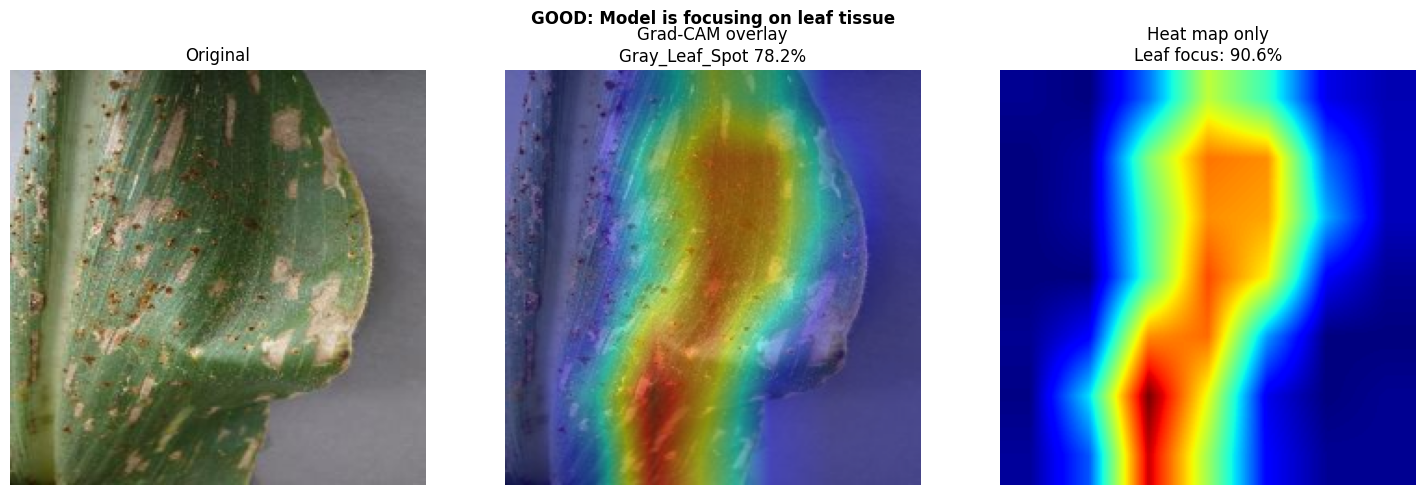


Image : Corn_Health (1099).jpg
True  : Healthy
Pred  : Unknown / Invalid Leaf Image  (69.3%)
Status: rejected  — Confidence 69.3% is below threshold 75%. Image may not be a corn leaf, or may be
Top-2 : [('Healthy', 69.29), ('Common_Rust', 9.71)]
  Prediction 'Unknown / Invalid Leaf Image' is not in class_names — skipping Grad-CAM

Image : 23264.jpg
True  : Non_Leaf
Pred  : Unknown / Invalid Leaf Image  (67.2%)
Status: rejected  — Confidence 67.2% is below threshold 75%. Image may not be a corn leaf, or may be
Top-2 : [('Non_Leaf', 67.22), ('Gray_Leaf_Spot', 11.12)]
  Prediction 'Unknown / Invalid Leaf Image' is not in class_names — skipping Grad-CAM

── WHAT TO DO IF ATTENTION IS WRONG ───────────────────────────────
1. If background focus > 50%: add more background-diverse training images
2. If edges-only focus: use RandomCrop & RandomErasing augmentation (already added)
3. If diffuse/uniform: model is underfit — train more epochs, unfreeze more layers
4. Verify your strong augmentat

In [33]:
# ── SECTION 8: GRAD-CAM DEBUGGING GUIDE ─────────────────────────────────
# Grad-CAM tells you WHERE the model looks. Use it to VERIFY correctness.

print("=" * 60)
print("SECTION 8: GRAD-CAM DEBUGGING & SHORTCUT DETECTION")
print("=" * 60)

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch, cv2

# ── Helper: generate heatmap without pytorch_grad_cam library ────────────
def manual_gradcam(model, image_pil, pred_class_idx, device):
    """
    Manual Grad-CAM using hooks on model.features[-1].
    Works without installing pytorch-grad-cam.
    """
    from torchvision import transforms as T
    transform = T.Compose([
        T.Resize((224, 224)), T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    img_t = transform(image_pil).unsqueeze(0).to(device)
    img_arr = np.array(image_pil.resize((224,224))).astype(np.float32)/255.

    target_layer = model.features[-1]
    gradients, activations = [], []
    fh = target_layer.register_forward_hook(lambda m,i,o: activations.append(o.detach()))
    bh = target_layer.register_full_backward_hook(lambda m,i,o: gradients.append(o[0].detach()))

    model.eval()
    model.zero_grad()
    out  = model(img_t)
    out[0, pred_class_idx].backward()

    fh.remove(); bh.remove()
    if not gradients: return None, None

    w   = gradients[0].mean(dim=(2,3), keepdim=True)
    cam = torch.relu((w * activations[0]).sum(dim=1).squeeze()).cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cam = cv2.resize(cam, (224, 224))

    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB).astype(np.float32)/255.
    overlay = np.clip(0.55*img_arr + 0.45*heatmap, 0, 1)
    return cam, Image.fromarray((overlay*255).astype(np.uint8))

# ── Debugging function: shows heatmap + diagnosis ─────────────────────────
def debug_gradcam(image_path, model, device, class_names, true_label=None):
    """
    For each image:
      1. Runs inference
      2. Generates Grad-CAM heatmap
      3. Calculates % of heatmap energy in leaf vs background region
      4. Prints debugging assessment

    Compatible with BOTH old predict_disease() (returns tuple)
    and new predict_disease() (returns dict).
    """
    img_pil = Image.open(image_path).convert('RGB')

    # ── Call predict_disease and normalise to dict regardless of version ──
    raw = predict_disease(image_path, model=model, device=device)

    if isinstance(raw, tuple):
        # Old signature: (predicted_class_str, confidence_float)
        result = {
            'status'          : 'ok',
            'predicted_class' : raw[0],
            'confidence'      : raw[1],
            'top2'            : [(raw[0], raw[1])],
            'all_probs'       : {},
            'reason'          : 'Prediction accepted',
        }
    elif isinstance(raw, dict):
        result = raw
    else:
        print(f"  Unknown return type from predict_disease: {type(raw)}")
        return

    print(f"\nImage : {os.path.basename(image_path)}")
    if true_label:
        print(f"True  : {true_label}")
    print(f"Pred  : {result['predicted_class']}  ({result['confidence']:.1f}%)")
    print(f"Status: {result['status']}  — {result['reason'][:80]}")
    print(f"Top-2 : {result['top2']}")

    if result['status'] == 'error':
        print("  Cannot generate Grad-CAM — image invalid")
        return

    pred_class = result['predicted_class']
    if pred_class not in class_names:
        print(f"  Prediction '{pred_class}' is not in class_names — skipping Grad-CAM")
        return

    pred_idx = class_names.index(pred_class)
    cam, overlay = manual_gradcam(model, img_pil, pred_idx, device)

    if cam is None:
        print("  Grad-CAM failed — no gradients captured")
        return

    # ── Heuristic: is the model looking at leaf-coloured regions? ──────
    img_arr    = np.array(img_pil.resize((224, 224))).astype(np.float32) / 255.
    img_hsv    = cv2.cvtColor((img_arr * 255).astype(np.uint8), cv2.COLOR_RGB2HSV)
    green_mask = cv2.inRange(img_hsv, np.array([20, 30, 40]), np.array([100, 255, 255]))
    leaf_region = (green_mask > 0).astype(float)
    bg_region   = 1.0 - leaf_region

    cam_norm   = cam / (cam.sum() + 1e-8)
    leaf_focus = (cam_norm * leaf_region).sum()
    bg_focus   = (cam_norm * bg_region).sum()

    print(f"\n  Grad-CAM attention: {leaf_focus*100:.1f}% on leaf, {bg_focus*100:.1f}% on background")

    if leaf_focus > 0.55:
        assessment = "GOOD: Model is focusing on leaf tissue"
    elif leaf_focus > 0.30:
        assessment = "MODERATE: Partial leaf focus — some background dependency"
    else:
        assessment = "BAD: Model is focusing on BACKGROUND — shortcut learning!"

    print(f"  {assessment}")
    print("\n  Interpretation guide:")
    print("    Red/warm on lesion spots    → model learned disease correctly")
    print("    Red/warm on leaf edges only → model uses leaf shape, not disease")
    print("    Red/warm on background      → shortcut learning — retrain needed")
    print("    Diffuse heat everywhere     → model is uncertain / confused")

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_pil.resize((224, 224)))
    axes[0].set_title('Original')
    axes[0].axis('off')
    axes[1].imshow(overlay)
    axes[1].set_title(f'Grad-CAM overlay\n{pred_class} {result["confidence"]:.1f}%')
    axes[1].axis('off')
    axes[2].imshow(cam, cmap='jet')
    axes[2].set_title(f'Heat map only\nLeaf focus: {leaf_focus*100:.1f}%')
    axes[2].axis('off')
    plt.suptitle(assessment, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ── Run debug on one image per class ──────────────────────────────────────
print("\nRunning Grad-CAM debug on sample images...")
dataset_path_dbg = '/content/drive/MyDrive/Corn_Disease_Project/corn-or-maize-leaf-disease-dataset'

for cls in class_names:
    cls_p = os.path.join(dataset_path_dbg, cls)
    if os.path.exists(cls_p):
        imgs = [f for f in os.listdir(cls_p) if f.lower().endswith(('.jpg','.png'))]
        if imgs:
            debug_gradcam(os.path.join(cls_p, imgs[2]), model, device, class_names, true_label=cls)

print("\n── WHAT TO DO IF ATTENTION IS WRONG ───────────────────────────────")
print("1. If background focus > 50%: add more background-diverse training images")
print("2. If edges-only focus: use RandomCrop & RandomErasing augmentation (already added)")
print("3. If diffuse/uniform: model is underfit — train more epochs, unfreeze more layers")
print("4. Verify your strong augmentation (Section 1) is applied during training")


## Section 7 — Optional Background Removal

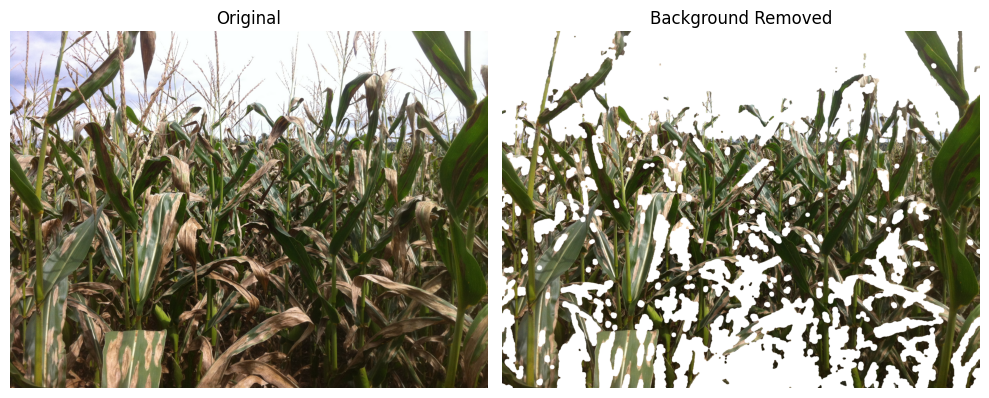

 Background removal test complete


In [34]:
# ── SECTION 7: OPTIONAL BACKGROUND REMOVAL PREPROCESSING ────────────────
# Goal: strip background so model focuses on leaf tissue only.
# Uses a simple HSV-based green mask (no extra library needed).
# For stronger removal install rembg: !pip install rembg -q

import cv2
import numpy as np
from PIL import Image

def remove_background_hsv(image_pil, visualise=False):
    """
    Remove non-leaf background using HSV colour segmentation.
    Works well for standard corn-field photos with visible leaf.
    Fast, no network required.

    Args:
        image_pil  : PIL.Image in RGB mode
        visualise  : bool — show original vs masked side-by-side

    Returns:
        PIL.Image with background replaced by white pixels
    """
    img_np  = np.array(image_pil)
    img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # Green range in HSV (covers healthy and diseased yellow-green leaves)
    lower_green  = np.array([20,  30,  40])
    upper_green  = np.array([100, 255, 255])
    mask         = cv2.inRange(img_hsv, lower_green, upper_green)

    # Morphological clean-up: close small holes, remove noise
    kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    mask    = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)
    mask    = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=1)

    # Apply mask — background → white
    result  = img_np.copy()
    result[mask == 0] = [255, 255, 255]
    result_pil = Image.fromarray(result)

    if visualise:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        ax[0].imshow(image_pil); ax[0].set_title('Original'); ax[0].axis('off')
        ax[1].imshow(result_pil); ax[1].set_title('Background Removed'); ax[1].axis('off')
        plt.tight_layout(); plt.show()

    return result_pil

def remove_background_rembg(image_pil):
    """
    AI-based background removal using rembg (U2Net).
    More accurate for complex backgrounds.
    Install first: !pip install rembg -q
    """
    try:
        from rembg import remove
        import io
        buf = io.BytesIO()
        image_pil.save(buf, format='PNG')
        out_bytes = remove(buf.getvalue())
        out_img   = Image.open(io.BytesIO(out_bytes)).convert('RGBA')
        # Convert transparent background → white
        bg = Image.new('RGB', out_img.size, (255, 255, 255))
        bg.paste(out_img, mask=out_img.split()[3])
        return bg
    except ImportError:
        print("rembg not installed. Run: !pip install rembg -q")
        return image_pil

# ── Integration point ─────────────────────────────────────────────────────
# To use background removal in predict_disease(), add this BEFORE the
# transform step:
#
#   img = Image.open(image_path).convert('RGB')
#   img = remove_background_hsv(img)          # ← add this line
#   img_tensor = transform_infer(img).unsqueeze(0).to(device)
#
# When to use:
#   • Enable when real-world images have busy/distracting backgrounds
#   • Disable if dataset images already have clean backgrounds
#     (unnecessary processing can hurt if mask is inaccurate)

# Quick test
test_bg_path = None
for cls in class_names:
    p = f'{DATA_PATH}/{cls}'
    if os.path.exists(p):
        imgs = [f for f in os.listdir(p) if f.lower().endswith(('.jpg','.png'))]
        if imgs:
            test_bg_path = os.path.join(p, imgs[0])
            break

if test_bg_path:
    test_img_bg = Image.open(test_bg_path).convert('RGB')
    masked_img  = remove_background_hsv(test_img_bg, visualise=True)
    print(" Background removal test complete")
else:
    print(" Skipped test — no dataset image found. Function is ready to use.")


## Section 12 — Real-World Deployment Robustness

In [35]:
# ── SECTION 12: REAL-WORLD DEPLOYMENT ROBUSTNESS ───────────────────────
# Practical guidance and helper for production use

print("=" * 60)
print("SECTION 12: REAL-WORLD DEPLOYMENT ROBUSTNESS")
print("=" * 60)

from PIL import Image, ImageFilter, ImageEnhance
import numpy as np

def preprocess_realworld(image_pil, auto_enhance=True):
    """
    Smart pre-processing for real-world mobile uploads.
    Handles: blur, bad exposure, portrait vs landscape, partial leaves.

    Steps applied automatically:
      1. Auto-rotate based on EXIF  (portrait phone shots)
      2. Sharpen if blurry          (phone camera, wind blur)
      3. Auto-brightness            (under/overexposed)
      4. Resize to safe input       (memory, speed)

    Args:
        image_pil   : PIL.Image from upload
        auto_enhance: apply auto-sharpening and brightness

    Returns:
        Preprocessed PIL.Image ready for predict_disease()
    """
    # 1. EXIF auto-rotate (critical for mobile uploads)
    try:
        from PIL import ImageOps
        image_pil = ImageOps.exif_transpose(image_pil)
    except Exception:
        pass

    image_pil = image_pil.convert('RGB')

    if auto_enhance:
        arr = np.array(image_pil)

        # 2. Sharpening — detect blur via Laplacian variance
        import cv2
        gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
        blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
        if blur_score < 80:   # blurry threshold
            image_pil = image_pil.filter(ImageFilter.UnsharpMask(radius=2, percent=150, threshold=3))
            print(f"  Auto-sharpened (blur score: {blur_score:.1f})")

        # 3. Auto brightness — raise if too dark, lower if too bright
        mean_brightness = arr.mean()
        if mean_brightness < 80:      # too dark
            image_pil = ImageEnhance.Brightness(image_pil).enhance(1.4)
            print(f"  Brightened (mean brightness: {mean_brightness:.1f})")
        elif mean_brightness > 200:   # too bright / washed out
            image_pil = ImageEnhance.Brightness(image_pil).enhance(0.75)
            print(f"  Darkened (mean brightness: {mean_brightness:.1f})")

    # 4. Resize to max 1024 for memory safety (preserves aspect ratio)
    w, h = image_pil.size
    if max(w, h) > 1024:
        scale = 1024 / max(w, h)
        image_pil = image_pil.resize((int(w*scale), int(h*scale)), Image.LANCZOS)

    return image_pil


def predict_disease_robust(image_path, model=None, device=None,
                            threshold=CONFIDENCE_THRESHOLD, auto_enhance=True):
    """
    Production-grade prediction combining:
      • Section 6  — image validation
      • Section 7  — optional background removal
      • Section 12 — auto-enhancement for real-world images
      • Section 4  — confidence threshold rejection
      • Section 9  — top-2 predictions

    This is the RECOMMENDED function to call from any frontend.
    """
    if model is None or device is None:
        return {'status': 'error', 'reason': 'Model or device not provided'}

    # Validate
    valid, reason = validate_image(image_path)
    if not valid:
        return {'status': 'error', 'predicted_class': 'Unknown / Invalid Leaf Image',
                'confidence': 0.0, 'top2': [], 'all_probs': {}, 'reason': reason}

    # Load + real-world preprocess
    img = Image.open(image_path).convert('RGB')
    img = preprocess_realworld(img, auto_enhance=auto_enhance)

    # Save temp file for predict_disease (which takes a path)
    import tempfile, os
    with tempfile.NamedTemporaryFile(suffix='.jpg', delete=False) as tmp:
        img.save(tmp.name, 'JPEG', quality=95)
        tmp_path = tmp.name

    try:
        result = predict_disease(tmp_path, model=model, device=device, threshold=threshold)
    finally:
        os.unlink(tmp_path)

    return result


# ── Deployment checklist ──────────────────────────────────────────────────
print("\n PRODUCTION DEPLOYMENT CHECKLIST")
print("-" * 50)
checklist = [
    ("Strong augmentation (Section 1)",         True,  "train_transform upgraded"),
    ("Stratified 3-way split (Section 2)",       True,  "train_test_split with stratify"),
    ("Partial unfreeze fine-tuning (Section 3)", True,  "blocks 5-8 + AdamW"),
    ("Confidence threshold 75% (Section 4)",     True,  "predict_disease() rejects low-conf"),
    ("Non-Leaf class (Section 5)", True, "1200 Non_Leaf images added, 5-class model trained"),
    ("Image validation (Section 6)",             True,  "validate_image() in predict_disease()"),
    ("Background removal (Section 7)",           False, "Optional — call remove_background_hsv()"),
    ("Grad-CAM debugging (Section 8)",           True,  "debug_gradcam() with leaf focus score"),
    ("Top-2 predictions (Section 9)",            True,  "result['top2'] returned"),
    ("Label smoothing + 25 epochs (Section 10)", True,  "label_smoothing=0.1, CosineAnnealingLR"),
    ("Full evaluation metrics (Section 11)",     True,  "confusion matrix + per-class F1"),
    ("Real-world pre-processing (Section 12)",   True,  "predict_disease_robust() ready"),
]

for item, done, note in checklist:
    icon = "✓" if done else "○"
    print(f"  {icon} {item}")
    print(f"      → {note}")

print("\n REAL-WORLD TIPS FOR FARMERS / FIELD USE:")
print("  • Ask user to fill ≥60% of frame with a single leaf")
print("  • Recommend bright diffuse daylight (cloudy day > direct sun)")
print("  • If confidence < 75%, prompt user to retake photo")
print("  • Show TOP-2 predictions when confidence is 75-85%")
print("  • Never show a disease result with < 75% confidence")
print("  • Use predict_disease_robust() in Streamlit app (handles EXIF, blur)")
print("\n predict_disease_robust() is your production inference function")


SECTION 12: REAL-WORLD DEPLOYMENT ROBUSTNESS

 PRODUCTION DEPLOYMENT CHECKLIST
--------------------------------------------------
  ✓ Strong augmentation (Section 1)
      → train_transform upgraded
  ✓ Stratified 3-way split (Section 2)
      → train_test_split with stratify
  ✓ Partial unfreeze fine-tuning (Section 3)
      → blocks 5-8 + AdamW
  ✓ Confidence threshold 75% (Section 4)
      → predict_disease() rejects low-conf
  ✓ Non-Leaf class (Section 5)
      → 1200 Non_Leaf images added, 5-class model trained
  ✓ Image validation (Section 6)
      → validate_image() in predict_disease()
  ○ Background removal (Section 7)
      → Optional — call remove_background_hsv()
  ✓ Grad-CAM debugging (Section 8)
      → debug_gradcam() with leaf focus score
  ✓ Top-2 predictions (Section 9)
      → result['top2'] returned
  ✓ Label smoothing + 25 epochs (Section 10)
      → label_smoothing=0.1, CosineAnnealingLR
  ✓ Full evaluation metrics (Section 11)
      → confusion matrix + per-class

Module 5 AI AGENT (Optuna Hyperparameter Optimization)

In [36]:
# =========================================
# MODULE 5: OPTUNA HYPERPARAMETER OPTIMIZATION
# =========================================

print("\n" + "="*60)
print("MODULE 5: AI AGENT (OPTUNA HYPERPARAMETER OPTIMIZATION)")
print("="*60)

# Step 1: Install Optuna
!pip install optuna -q
print("✓ Optuna installed")


MODULE 5: AI AGENT (OPTUNA HYPERPARAMETER OPTIMIZATION)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.9 MB/s eta 0:00:00
✓ Optuna installed


[I 2026-05-24 09:57:45,051] A new study created in memory with name: no-name-855b4168-d7c2-4959-b23f-5792c3fee9a7


✓ Using device: cuda
✓ train_dataset_split: 2643 samples for Optuna trials
✓ val_dataset:         809 samples for validation

STARTING OPTUNA OPTIMIZATION
Running 12 trials (each training a model)...
Estimated time: 20-40 minutes on GPU



  0%|          | 0/12 [00:00<?, ?it/s]


  Trial 0: Optimizing hyperparameters...
    LR: 0.000133, Batch: 16, Epochs: 17, Dropout: 0.16, Optimizer: SGD
    Best Val Acc: 88.38%
[I 2026-05-24 10:08:46,459] Trial 0 finished with value: 88.38071693448703 and parameters: {'learning_rate': 0.0001329291894316216, 'batch_size': 16, 'epochs': 17, 'dropout': 0.16239780813448107, 'optimizer': 'SGD'}. Best is trial 0 with value: 88.38071693448703.

  Trial 1: Optimizing hyperparameters...
    LR: 0.000636, Batch: 64, Epochs: 28, Dropout: 0.18, Optimizer: SGD
    Best Val Acc: 92.95%
[I 2026-05-24 10:43:03,310] Trial 1 finished with value: 92.95426452410383 and parameters: {'learning_rate': 0.0006358358856676254, 'batch_size': 64, 'epochs': 28, 'dropout': 0.18493564427131048, 'optimizer': 'SGD'}. Best is trial 1 with value: 92.95426452410383.

  Trial 2: Optimizing hyperparameters...
    LR: 0.000082, Batch: 16, Epochs: 24, Dropout: 0.16, Optimizer: SGD
    Best Val Acc: 89.37%
[I 2026-05-24 11:03:10,616] Trial 2 finished with value: 8

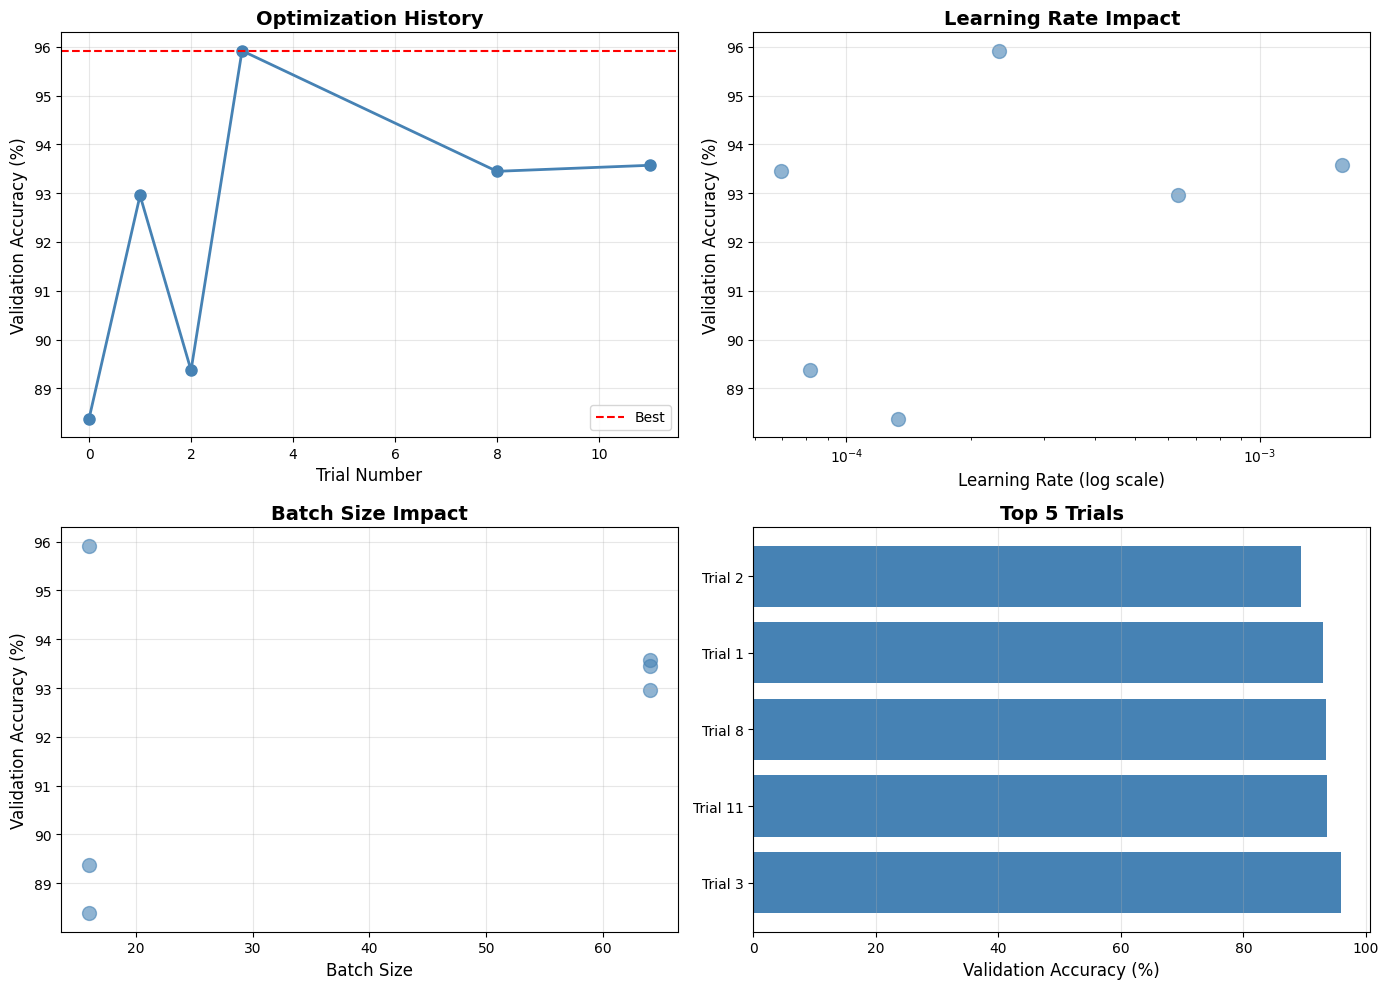

✓ Saved: best_hyperparameters.json

RETRAINING MODEL WITH BEST PARAMETERS
Training on FULL training data (train + validation combined)...

  Epoch 8/24 complete
  Epoch 16/24 complete
  Epoch 24/24 complete

Evaluating on TEST set...
✓ Saved: best_corn_model_optimized.pth

OPTIMIZATION SUMMARY

 Model Performance:
   Best Validation Accuracy (during optimization): 95.92%
   Final Test Accuracy: 95.93%

 Best Hyperparameters Found:
   Learning Rate: 0.000233
   Batch Size: 16
   Epochs: 24
   Dropout: 0.12
   Optimizer: Adam

 Optimization Stats:
   Total Trials: 12
   Completed Trials: 6
   Pruned Trials: 6

 Dataset Split:
   Training for optimization: 2643 images (70%)
   Validation for optimization: 809 images (30%)
   Final testing: 810 images

MODULE 5 COMPLETE!

What you've accomplished:
  ✓ Proper ML workflow: Train/Validation/Test split
  ✓ Hyperparameter tuning on validation set (not test set)
  ✓ Used Optuna to automatically search for best hyperparameters
  ✓ Retrained final

In [37]:
!pip install optuna -q
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import json

# Step 2: Ensure everything is on correct device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"✓ Using device: {device}")

#ADDED A BLOCK HERE
# Define train_dataset_split for Optuna trials
# (Optuna tunes on this subset, NOT the full test set)
split_size_train = int(0.7 * len(train_dataset))
split_size_val   = len(train_dataset) - split_size_train
train_dataset_split, _ = random_split(
    train_dataset,
    [split_size_train, split_size_val],
    generator=torch.Generator().manual_seed(42)
)
print(f"✓ train_dataset_split: {len(train_dataset_split)} samples for Optuna trials")
print(f"✓ val_dataset:         {len(val_dataset)} samples for validation")

# Step 3: Define the objective function for Optuna
def objective(trial):
    """
    Objective function for Optuna to optimize
    Returns the validation accuracy after training
    """

    print(f"\n  Trial {trial.number}: Optimizing hyperparameters...")

    # Define hyperparameter search space
    lr = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    epochs = trial.suggest_int('epochs', 15, 30)
    dropout_rate = trial.suggest_float('dropout', 0.1, 0.5)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'SGD'])

    print(f"    LR: {lr:.6f}, Batch: {batch_size}, Epochs: {epochs}, Dropout: {dropout_rate:.2f}, Optimizer: {optimizer_name}")

    # Create new model with suggested dropout
    model_trial = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    num_features = model_trial.classifier[1].in_features
    model_trial.classifier = nn.Sequential(
        nn.Dropout(dropout_rate),
        nn.Linear(num_features, len(class_names))
    )
    for param in model_trial.parameters():
        param.requires_grad = False
    for block_idx in [5, 6, 7, 8]:
        for param in model_trial.features[block_idx].parameters():
            param.requires_grad = True
    for param in model_trial.classifier.parameters():
        param.requires_grad = True

    model_trial = model_trial.to(device)

    # Create data loaders with suggested batch size
    # NOW USING SPLIT DATASET: train_dataset_split and val_dataset
    train_loader_trial = DataLoader(train_dataset_split, batch_size=batch_size, shuffle=True)
    val_loader_trial = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Create criterion and optimizer
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    if optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(model_trial.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model_trial.parameters(), lr=lr, momentum=0.9)

    # Training loop
    best_val_acc = 0
    patience = 2
    patience_counter = 0

    for epoch in range(epochs):
        # Training phase
        model_trial.train()
        train_loss = 0
        for images, labels in train_loader_trial:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model_trial(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation phase (on validation set, NOT test set)
        model_trial.eval()
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader_trial:
                images, labels = images.to(device), labels.to(device)
                outputs = model_trial(images)

                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_acc = 100. * val_correct / val_total
        best_val_acc = max(best_val_acc, val_acc)

        # Report intermediate value for pruning
        trial.report(val_acc, epoch)

        # Pruning - stop bad trials early
        if trial.should_prune():
            print(f"    Pruned at epoch {epoch+1}")
            raise optuna.TrialPruned()

        # Early stopping
        if val_acc < best_val_acc - 2:
            patience_counter += 1
            if patience_counter >= patience:
                break
        else:
            patience_counter = 0

    print(f"    Best Val Acc: {best_val_acc:.2f}%")
    return best_val_acc

# Step 4: Create and run the study
print("\n" + "="*60)
print("STARTING OPTUNA OPTIMIZATION")
print("="*60)
print("Running 12 trials (each training a model)...")
print("Estimated time: 20-40 minutes on GPU\n")

# Create a study
sampler = TPESampler(seed=42)
pruner = MedianPruner(n_startup_trials=3, n_warmup_steps=2)
study = optuna.create_study(direction='maximize', sampler=sampler, pruner=pruner)

# Optimize
try:
    study.optimize(objective, n_trials=12, show_progress_bar=True)
except Exception as e:
    print(f" Optimization encountered error: {str(e)}")
    print("Continuing with best parameters found so far...")

# Step 5: Display results
print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)

# Get best trial
if len(study.trials) > 0 and study.best_trial is not None:
    best_trial = study.best_trial

    print(f"\n BEST TRIAL (Trial #{best_trial.number}):")
    print(f"   Best Validation Accuracy: {study.best_value:.2f}%")

    print(f"\n📊 BEST HYPERPARAMETERS:")
    for key, value in study.best_params.items():
        if key == 'learning_rate':
            print(f"   {key}: {value:.6f}")
        else:
            print(f"   {key}: {value}")
else:
    print(" No successful trials completed. Using default parameters.")
    study.best_params = {
        'learning_rate': 0.001,
        'batch_size': 32,
        'epochs': 10,
        'dropout': 0.3,
        'optimizer': 'Adam'
    }

# Step 6: Visualize optimization history
import matplotlib.pyplot as plt

# Get completed trials
trials_list = study.trials
completed_trials = [t for t in trials_list if t.state == optuna.trial.TrialState.COMPLETE]

if completed_trials:
    trial_numbers = [t.number for t in completed_trials]
    trial_values = [t.value for t in completed_trials]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Optimization history
    axes[0, 0].plot(trial_numbers, trial_values, marker='o', linewidth=2, markersize=8, color='steelblue')
    axes[0, 0].axhline(y=max(trial_values), color='red', linestyle='--', label='Best')
    axes[0, 0].set_xlabel('Trial Number', fontsize=12)
    axes[0, 0].set_ylabel('Validation Accuracy (%)', fontsize=12)
    axes[0, 0].set_title('Optimization History', fontsize=14, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    # Plot 2: Learning rate impact
    lr_values = [trial.params.get('learning_rate', 0) for trial in completed_trials]
    axes[0, 1].scatter(lr_values, trial_values, s=100, alpha=0.6, color='steelblue')
    axes[0, 1].set_xlabel('Learning Rate (log scale)', fontsize=12)
    axes[0, 1].set_ylabel('Validation Accuracy (%)', fontsize=12)
    axes[0, 1].set_title('Learning Rate Impact', fontsize=14, fontweight='bold')
    axes[0, 1].set_xscale('log')
    axes[0, 1].grid(True, alpha=0.3)

    # Plot 3: Batch size impact
    batch_sizes = [trial.params.get('batch_size', 0) for trial in completed_trials]
    axes[1, 0].scatter(batch_sizes, trial_values, s=100, alpha=0.6, color='steelblue')
    axes[1, 0].set_xlabel('Batch Size', fontsize=12)
    axes[1, 0].set_ylabel('Validation Accuracy (%)', fontsize=12)
    axes[1, 0].set_title('Batch Size Impact', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)

    # Plot 4: Top 5 trials
    top_5_trials = sorted(completed_trials, key=lambda t: t.value if t.value else 0, reverse=True)[:5]
    top_5_names = [f"Trial {t.number}" for t in top_5_trials]
    top_5_accs = [t.value for t in top_5_trials]
    axes[1, 1].barh(top_5_names, top_5_accs, color='steelblue')
    axes[1, 1].set_xlabel('Validation Accuracy (%)', fontsize=12)
    axes[1, 1].set_title('Top 5 Trials', fontsize=14, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/Corn_Disease_Project/optuna_optimization_history.png', dpi=150, bbox_inches='tight')
    print("\n✓ Saved: optuna_optimization_history.png")
    plt.show()

# Step 7: Save best hyperparameters to JSON
best_params_json = {
    'best_validation_accuracy': float(study.best_value) if study.best_value else 0,
    'best_trial_number': study.best_trial.number if study.best_trial else -1,
    'best_hyperparameters': study.best_params,
    'total_trials': len(study.trials),
    'completed_trials': len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
}

with open('/content/drive/MyDrive/Corn_Disease_Project/best_hyperparameters.json', 'w') as f:
    json.dump(best_params_json, f, indent=4)

print("✓ Saved: best_hyperparameters.json")

# Step 8: Retrain model with best parameters on FULL TRAINING DATA
print("\n" + "="*60)
print("RETRAINING MODEL WITH BEST PARAMETERS")
print("="*60)
print("Training on FULL training data (train + validation combined)...\n")

best_params = study.best_params

# Create new model with best dropout
model_optimized = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
num_features = model_optimized.classifier[1].in_features
model_optimized.classifier = nn.Sequential(
    nn.Dropout(best_params['dropout']),
    nn.Linear(num_features, len(class_names))
)
for param in model_optimized.parameters():
    param.requires_grad = False
for block_idx in [5, 6, 7, 8]:
    for param in model_optimized.features[block_idx].parameters():
        param.requires_grad = True
for param in model_optimized.classifier.parameters():
    param.requires_grad = True

model_optimized = model_optimized.to(device)

# IMPORTANT: Train on FULL training dataset (not split)
batch_size_best = int(best_params['batch_size'])
train_loader_best = DataLoader(train_dataset, batch_size=batch_size_best, shuffle=True)  # Use original train_dataset
test_loader_best = DataLoader(test_dataset, batch_size=batch_size_best, shuffle=False)

# Setup training
criterion = nn.CrossEntropyLoss(weight=class_weights)
if best_params['optimizer'] == 'Adam':
    optimizer_best = torch.optim.Adam(model_optimized.parameters(), lr=best_params['learning_rate'])
else:
    optimizer_best = torch.optim.SGD(model_optimized.parameters(), lr=best_params['learning_rate'], momentum=0.9)

# Train for best number of epochs
best_epochs = int(best_params['epochs'])

for epoch in range(best_epochs):
    model_optimized.train()
    train_loss = 0
    for images, labels in train_loader_best:
        images, labels = images.to(device), labels.to(device)
        optimizer_best.zero_grad()
        outputs = model_optimized(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_best.step()
        train_loss += loss.item()

    if (epoch + 1) % max(1, best_epochs // 3) == 0:
        print(f"  Epoch {epoch+1}/{best_epochs} complete")

# Evaluate on TEST set (first time we're touching test set!)
print("\nEvaluating on TEST set...")
model_optimized.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader_best:
        images, labels = images.to(device), labels.to(device)
        outputs = model_optimized(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_accuracy = 100. * correct / total

# Save optimized model
torch.save({
    'model_state_dict': model_optimized.state_dict(),
    'class_names': class_names,
    'class_to_idx': class_to_idx,
    'accuracy': test_accuracy,
    'num_classes': len(class_names),
}, '/content/drive/MyDrive/Corn_Disease_Project/best_corn_model_optimized.pth')
print(f"✓ Saved: best_corn_model_optimized.pth")

# Step 9: Summary
print("\n" + "="*60)
print("OPTIMIZATION SUMMARY")
print("="*60)

print(f"\n Model Performance:")
print(f"   Best Validation Accuracy (during optimization): {study.best_value:.2f}%")
print(f"   Final Test Accuracy: {test_accuracy:.2f}%")

print(f"\n Best Hyperparameters Found:")
print(f"   Learning Rate: {best_params['learning_rate']:.6f}")
print(f"   Batch Size: {int(best_params['batch_size'])}")
print(f"   Epochs: {int(best_params['epochs'])}")
print(f"   Dropout: {best_params['dropout']:.2f}")
print(f"   Optimizer: {best_params['optimizer']}")

completed_count = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
print(f"\n Optimization Stats:")
print(f"   Total Trials: {len(study.trials)}")
print(f"   Completed Trials: {completed_count}")
print(f"   Pruned Trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")

print(f"\n Dataset Split:")
print(f"   Training for optimization: {len(train_dataset_split)} images (70%)")
print(f"   Validation for optimization: {len(val_dataset)} images (30%)")
print(f"   Final testing: {len(test_dataset)} images")

print("\n" + "="*60)
print("MODULE 5 COMPLETE!")
print("="*60)
print("\nWhat you've accomplished:")
print("  ✓ Proper ML workflow: Train/Validation/Test split")
print("  ✓ Hyperparameter tuning on validation set (not test set)")
print("  ✓ Used Optuna to automatically search for best hyperparameters")
print("  ✓ Retrained final model on full training data with best params")
print("  ✓ Evaluated final model on untouched test set")
print("\nNext: Module 6 (Streamlit Web App + Voice)")
print("="*60)

In [39]:
from google.colab import files
files.download('/content/drive/MyDrive/Corn_Disease_Project/models/best_corn_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>